
# <font color="red"> Redes Neuronales Recurrentes</font>

## <font color="blue"> Por Alfredo Alfredo Diaz </font>

El objetivo de esta sección es aprender y practicar redes neuronales recurrentes (RNN) en diversas tareas y aplicaciones, siendo la primera de ellas el análisis de datos de series temporales. Las RNN han revolucionado la forma en que se pronostica la información secuencial.

* Ver este enlace animado https://joshvarty.github.io/VisualizingRNNs/


* Ver explicación detallada https://colab.research.google.com/drive/1beXNFH-VT7fbefc2_hG8P1VLOTljh3UT?usp=sharing


In [ ]:
%%html
<iframe src=" https://joshvarty.github.io/VisualizingRNNs/" width="100%" height=800></iframe>

## 📋 Tabla de Contenidos — Cuaderno 10

> **Posición en el curso**: Este cuaderno es el **Módulo 10** y debe estudiarse **antes** del Módulo 11 (NLP con Embeddings).  
> Aquí aprenderá la base matemática y práctica de las RNNs. El Módulo 11 usará estas redes para procesar lenguaje natural.

---

1. [¿Qué es una RNN? Intuición y arquitectura](#1-que-es-una-rnn)
2. [Matemática de las RNNs: Forward y Backward Pass](#2-matematica)
3. [Tipos de RNN (one-to-one, one-to-many…)](#3-tipos)
4. [Representación de texto: One-Hot vs Embedding](#4-representacion)
5. [Ejemplo 1 — RNN simple: predicción de series temporales](#5-series)
6. [Ejemplo 2 — Generación de nombres con SimpleRNN / LSTM / GRU](#6-nombres)
7. [El Problema del Gradiente Desvanecido](#7-gradiente)
8. [LSTM: arquitectura detallada y ecuaciones](#8-lstm)
9. [GRU: la alternativa eficiente al LSTM](#9-gru)
10. [Ejemplo 3 — Generación de texto (Alicia en el País de las Maravillas)](#10-texto)
11. [Ejemplo 4 — Predicción de precio de acciones (Tesla)](#11-acciones)
12. [¿Cuántas capas y neuronas usar? Guía práctica](#12-guia)
13. [Resumen comparativo y cuándo usar cada arquitectura](#13-resumen)
14. [Ejercicios propuestos](#14-ejercicios)

---
> **Prerrequisitos**: Python, NumPy, TensorFlow/Keras, scikit-learn, matplotlib


---

# 🧠 1. ¿Qué es una Red Neuronal Recurrente? — Intuición

---

## Limitación de las redes feedforward tradicionales

Las redes neuronales **densas (MLP)** y **convolucionales (CNN)** procesan cada entrada de forma **independiente**: no tienen noción del orden ni del contexto anterior.

Esto es un problema cuando los datos tienen estructura **temporal** o **secuencial**:

| Tipo de dato | ¿Por qué importa el orden? |
|---|---|
| Texto | "El banco del río" ≠ "Fui al banco a pagar" |
| Audio / Habla | Las sílabas forman palabras en secuencia |
| Series temporales | El precio de hoy depende del precio de ayer |
| Video | Los fotogramas tienen continuidad temporal |
| ADN | La secuencia de bases importa |

## La solución: memoria interna

Una **RNN** agrega un **estado oculto** $h_t$ que actúa como memoria: captura lo que ocurrió en los pasos anteriores y lo combina con la entrada actual.

```
Paso 1:   x₁ → [RNN] → h₁
Paso 2:   x₂ → [RNN] + h₁ → h₂
Paso 3:   x₃ → [RNN] + h₂ → h₃   → ŷ
```

La misma celda RNN se aplica en **cada paso de tiempo**, compartiendo sus pesos. Esto le permite generalizar a secuencias de cualquier longitud.

## Analogía pedagógica

Imagina que estás leyendo un libro palabra por palabra. Tu cerebro no procesa cada palabra de forma aislada: recuerda las palabras anteriores para entender el significado de la actual.

Una RNN hace algo parecido: **acumula contexto** a medida que avanza en la secuencia.

## Representación visual

```
        ┌─────┐        ┌─────┐        ┌─────┐
h₀ ─→   │ RNN │─ h₁ →  │ RNN │─ h₂ →  │ RNN │─ h₃ → ŷ
        │     │        │     │        │     │
    x₁ ─┘     └─   x₂ ─┘     └─   x₃ ─┘
```

Los pesos **W, U, V** son los mismos en cada paso (parámetros compartidos).




En una red neuronal recurrente, se guardan (memoria) las activaciones de salida de una o más capas de la red. A menudo, estas activaciones son de las capas ocultas. Luego, la próxima vez que alimentamos un ejemplo de entrada a la red, incluimos las salidas almacenadas previamente como entradas adicionales. Estas entradas adicionales como si estuvieran concatenadas al final de las entradas “normales” de la capa anterior.

 Por ejemplo, si una capa oculta tiene 10 nodos de entrada regulares y 128 nodos ocultos en la capa, entonces tendría en realidad un total de 138 entradas. Por supuesto, la primera vez que intentas calcular la salida de la red, necesitarás rellenar esas 128 entradas adicionales con ceros o algo similar.

![image](https://github.com/adiacla/RNN/blob/main/rnn.png?raw=true)



Las redes neuronales recurrentes (En inglés Recurrent Neural Networks - RNN) son una familia de redes neuronales para procesar datos secuenciales, las cuales se basan en el principio de compartir parámetros a lo largo de diferentes partes del modelo, lo que permite aplicar el modelo a datos con estructuras diferentes y generalizar sobre ellos.

Si por el contrario se tuviera un párametro para cada índice de tiempo, no se podría generalizar a longitudes de secuencias no vistas durante el entrenamiento, o compartir patrones detectados por el modelo a lo largo de diferentes longitudes de secuencias y posiciones en el tiempo; dicha propiedad es particularmente importante cuando una pieza de información específica puede ocurrir en múltiples posiciones dentro de una secuencia.

La red permanece Feed-forward pero mantiene el estado interno a través de nodos de contexto los cuales influencian la capa oculta en entradas subsecuentes. Existen diferentes arquitecturas de RNN, las más conocidas son las Elman y Jordan como se aprecia la siguiente imagen.

![image](https://raw.githubusercontent.com/jdariasl/ML_2020/a4f7f015e29b279db380dd51f1a5e379fd3d4ae4//Images/RNN2.png)

# Ejemplo básico de RNN con SimpleRnn

In [1]:
# ==========================================
# Introducción a RNN: Predicción de series temporales
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Input
from sklearn.preprocessing import MinMaxScaler


## Generación de datos

Creamos una serie temporal senoidal con ruido (algo parecido a lo que ocurre con señales físicas o financieras).
Esto nos da un patrón periódico pero imperfecto → ideal para mostrar cómo la RNN aprende dependencias temporales.

In [ ]:

# ==========================================
# Generación de datos sintéticos
# ==========================================

# Función que genera una serie senoidal con algo de ruido
def generate_time_series(n_samples=1000, n_timesteps=50, freq=0.1):
    time = np.linspace(0, n_timesteps * freq, n_timesteps)
    # Serie base: senoidal + ruido
    series = np.sin(2 * np.pi * time) + 0.1 * np.random.randn(n_timesteps)
    return series

# Generamos una serie
series = generate_time_series()

series

In [ ]:
time=np.round(np.linspace(0, 50 * 0.1,50)*10,0)
time

In [ ]:
len(series),series.shape

In [ ]:
# Exploramos visualmente la serie
plt.figure(figsize=(8,4))
plt.plot(series, label='Serie original')
plt.title("Serie temporal sintética (senoidal con ruido)")
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.legend()
plt.show()


## Normalización

Las redes neuronales aprenden mejor cuando los datos están en un rango pequeño, por eso usamos MinMaxScaler → [0, 1].

Aunque el rango sea -1 a 1, hay dos razones prácticas por las que se sigue normalizando

a. Cuando hay ruido o desbalance en la escala

b. Por coherencia con pipelines reales: En problemas reales, los datos casi nunca están perfectamente escalados.

Por eso, en la práctica, se normaliza siempre para que la red reciba entradas en una escala controlada.

In [ ]:
# ==========================================
# Preparación de los datos para la RNN
# ==========================================

# Normalizamos los datos para que la red aprenda mejor
scaler = MinMaxScaler(feature_range=(0, 1))
series_scaled = scaler.fit_transform(series.reshape(-1, 1))


In [ ]:
#Graficar los datos escalados
plt.figure(figsize=(8,4))
plt.plot(series_scaled, label='Serie original', color='orange')
plt.title("Serie temporal sintética con datos escalados (senoidal con ruido)")
plt.xlabel("Tiempo")
plt.ylabel("Valor")


In [ ]:
#Mostrar la tabla de datos de los primero 20 x y el tiempo en un df
import pandas as pd
df=pd.DataFrame(series_scaled[:20])
df.columns=['Valor']
df.index=time[:20]
df


Creación de secuencias

Una RNN no trabaja con un solo número, sino con una secuencia de pasos anteriores.
Ejemplo: si window_size=10, la red verá los últimos 10 valores y tratará de predecir el 11º.

In [ ]:
# Función para crear secuencias (ventanas deslizantes)
def create_sequences(data, window_size=10):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

window_size = 10
X, y = create_sequences(series_scaled, window_size)

In [ ]:
#Veamos la primera secuencia
X[0]

In [ ]:
X[1]

In [ ]:
y

In [ ]:
X.shape

In [ ]:
# Redimensionamos X para que tenga la forma [muestras, pasos temporales, características]
X = X.reshape((X.shape[0], X.shape[1], 1))

print(f"Forma de X: {X.shape}")
print(f"Forma de y: {y.shape}")

In [ ]:
X

In [ ]:
y

entonces:

Tienes 40 ventanas (muestras).

Cada ventana tiene 10 pasos de tiempo.

Cada paso tiene 1 característica.

In [ ]:
# Primera ventana
primera_ventana = X[0]        # Toma la primera muestra -> forma (10, 1)
print(primera_ventana.shape)
print(primera_ventana)

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(np.arange(window_size), primera_ventana, label='Primera ventana')
plt.plot(window_size, y[0], 'o', label='y de la primera ventana', color='orange') # Plot y[0] as a single point at the next time step
plt.title("Primera ventana de datos y el valor correspondiente")
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.show()

## Modelo RNN

La capa SimpleRNN tiene 32 neuronas y usa activación tanh (adecuada para datos continuos).
Después, una capa Dense(1) genera la predicción del siguiente valor.

In [ ]:
# ==========================================
# Construcción del modelo RNN
# ==========================================

model = Sequential([
    Input(shape=(window_size, 1)),
    SimpleRNN(units=32, activation='tanh'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()


In [ ]:
from tensorflow.keras.utils import plot_model
plot_model(
    model,
    to_file="rnn_model.png",
    show_shapes=True,
    show_layer_names=True,
    show_dtype=False,
    show_layer_activations=True
)


![](https://raw.githubusercontent.com/adiacla/bigdata/refs/heads/master/SimpleRNN.png)

## Entrenamiento y validación

Entrenamos con el 80% de los datos y validamos con el 20%.
La pérdida MSE (error cuadrático medio) muestra si la red aprende el patrón de la serie.

In [ ]:
# ==========================================
# Entrenamiento del modelo
# ==========================================

history = model.fit(X, y, epochs=50, batch_size=16, validation_split=0.2, verbose=1)

# Visualizamos la pérdida (MSE)
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Evolución del error (MSE)')
plt.xlabel('Épocas')
plt.ylabel('Error')
plt.legend()
plt.show()


## Predicción

Tomamos la última ventana de la serie y predecimos el siguiente valor.
La gráfica muestra el punto rojo como el valor predicho.

In [ ]:
# ==========================================
# Predicción con la RNN
# ==========================================

# Tomamos los últimos 10 puntos de la serie como entrada
last_window = series_scaled[-window_size:].reshape(1, window_size, 1)
predicted_scaled = model.predict(last_window)

# Desnormalizamos la predicción
predicted = scaler.inverse_transform(predicted_scaled)

print(f"Predicción del siguiente valor: {predicted[0][0]:.4f}")

# Visualizamos el resultado
plt.figure(figsize=(8,4))
plt.plot(series, label='Serie original')
plt.axvline(x=len(series)-window_size, color='gray', linestyle='--', label='Ventana usada')
plt.scatter(len(series), predicted[0][0], color='red', label='Predicción')
plt.title('Predicción del siguiente valor de la serie')
plt.xlabel('Tiempo')
plt.ylabel('Valor')
plt.legend()
plt.show()

In [ ]:
# ==========================================
# Predicción con la RNN
# ==========================================

# Tomamos los últimos 'window_size' puntos de la serie como entrada
last_window = series_scaled[-window_size:].flatten().tolist() # Flatten and convert to list

# Lista para almacenar las predicciones futuras
predicted_scaled_values = []

# Realizamos predicciones para los próximos 3 pasos

num_predictions = 9
for _ in range(num_predictions):
    # Reshape the last_window for prediction
    input_sequence = np.array(last_window[-window_size:]).reshape(1, window_size, 1)

    # Predict the next value
    next_prediction_scaled = model.predict(input_sequence, verbose=0)[0][0]

    # Append the prediction to the list
    predicted_scaled_values.append(next_prediction_scaled)

    # Add the predicted value to the last_window to use for the next prediction
    last_window.append(next_prediction_scaled)


# Desnormalizamos las predicciones
predicted_values = scaler.inverse_transform(np.array(predicted_scaled_values).reshape(-1, 1))

print(f"Predicción de los próximos {num_predictions} valores:")
for i, pred in enumerate(predicted_values):
    print(f"Paso {i+1}: {pred[0]:.4f}")


# Visualizamos el resultado
plt.figure(figsize=(10,6))
plt.plot(series, label='Serie original')

# Plot the original series data points used for the last window
plt.plot(np.arange(len(series) - window_size, len(series)), series[-window_size:], color='orange', label='Ventana usada para predicción inicial')



# Plot the predicted values
# We need to determine the x-axis values for the predictions
last_index = len(series) -1
predicted_indices = np.arange(last_index + 1, last_index + 1 + num_predictions)
plt.plot(predicted_indices, predicted_values.flatten(), color='red', linestyle='--', marker='o', label=f'Predicciones ({num_predictions} pasos)')

plt.title(f'Predicción de los próximos {num_predictions} valores de la serie')
plt.xlabel('Tiempo')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.show()


#Tipos de RNN
Las redes prealimentadas tienen entrada y salida únicas, mientras que las redes neuronales recurrentes son flexibles, ya que se puede cambiar la longitud de las entradas y las salidas. Esta flexibilidad permite a las RNN generar música, clasificación de sentimiento y traducción automática.

Hay cuatro tipos de RNN basados en diferentes longitudes de entradas y salidas.

**Uno a uno** es una red neuronal sencilla. Se suele utilizar para problemas de machine learning que tienen entrada y salida únicas.

**Uno a muchos** tiene entrada única y varias salidas. Se utiliza  por ejemplo en generar comentarios de foto.

**Muchos a uno** toma una secuencia de varias entradas y predice una salida única. Es popular en la clasificación de sentimiento, donde la entrada es texto y la salida es una categoría.

**Muchos a muchos** toma varias entradas y salidas. La aplicación más común es la traducción automática.

![image](https://raw.githubusercontent.com/jdariasl/ML_2020/a4f7f015e29b279db380dd51f1a5e379fd3d4ae4/Images/RNN-Topol.jpeg)

Retomando la definición, una red neuronal recurrente (RNN) es un tipo de red neuronal especializada en el procesamiento de secuencias de datos
$x(t)=x(1),…,x(τ)$, donde el índice de tiempo
$𝑡$ varía desde 1 hasta $τ$. Para tareas que involucran entradas secuenciales, como el habla y el lenguaje, a menudo es mejor utilizar RNNs.

En un problema de procesamiento de lenguaje natural (NLP), si deseas predecir la siguiente palabra en una oración, es importante conocer las palabras que la preceden. Las RNNs se llaman recurrentes porque realizan la misma tarea para cada elemento de una secuencia, con la salida dependiendo de los cálculos previos. Otra forma de pensar en las RNNs es que tienen una "memoria" que captura información sobre lo que se ha calculado hasta el momento.

![image](https://github.com/adiacla/RNN/blob/main/rnn2.png?raw=true)

Tomado del libro de Chollet, F., & Allaire, J. (2021). Recurrent neural networks

El lado izquierdo del diagrama anterior muestra la notación de una RNN y, en el lado derecho, una RNN desenrollada (o desplegada) en una red completa. Es decir si se despliega la red en detalle, se observa toda  la secuencia. Por ejemplo, si la secuencia que nos interesa es una oración de 3 palabras, la red se fija en una red neuronal de 3 capas, una capa para cada palabra.


# Repaso de las fórmulas básicas usadas

## Entrada

x(t) se toma como entrada a la red en el instante de tiempo t. Por ejemplo,  $𝑥_1$  podría ser un vector one-hot correspondiente a una palabra de la oración.

## Estado oculto

h(t) representa el estado oculto en el tiempo 𝑡 y actúa como la "memoria" de la red.

h(t) se calcula en función de la entrada actual y el estado oculto del paso de tiempo anterior:

$h^{(t)}=f(Ux^{(t)}+Wh^{(t−1)})$

La función 𝑓 se elige como una transformación no lineal, como
*tanh* o *ReLU*.

## Pesos

La RNN tiene conexiones de entrada a estado oculto parametrizadas por una matriz de pesos 𝑈, conexiones recurrentes de estado oculto a estado oculto parametrizadas por una matriz de pesos 𝑊, y conexiones de estado oculto a salida parametrizadas por una matriz de pesos 𝑉. Todos estos pesos $(U,V,W)$ se comparten a lo largo del tiempo.

## Salida

o(t) ilustra la salida de la red. En el diagrama, he añadido una flecha después de $o(t)$, que también suele estar sujeta a no linealidad, especialmente cuando la red contiene más capas hacia abajo.


## Paso hacia adelante o Forward Pass

La figura no especifica la elección de la función de activación para las unidades ocultas. Antes de continuar, hacemos algunas suposiciones:

1. Se asumime que la función de activación tangente hiperbólica se utiliza para la capa oculta;

2. Se asumime que la salida es discreta, como si la RNN se utilizara para predecir palabras o caracteres.

Una forma natural de representar variables discretas es considerar que la salida 𝑜 proporciona las probabilidades logarítmicas no normalizadas de cada valor posible de la variable discreta.

Luego, podemos aplicar la operación softmax como un paso de post-procesamiento para obtener un vector $ŷ$  de probabilidades normalizadas sobre la salida.


El paso hacia adelante de la RNN se puede representar mediante el siguiente conjunto de ecuaciones.

$$a^{(t)}= b+Wh^{(t-1)}+Ux^{(t)}$$
$$h^{(t)}= tanh (a^{(t)})$$
$$\sigma^{(t)}= c+Vh^{(t)}$$
$$\hat{y}^{(t)}= softmax(\sigma^{(t)})$$


Este es un ejemplo de una red recurrente que mapea una secuencia de entrada a una secuencia de salida de la misma longitud. La pérdida total para una secuencia dada de valores 𝑥 emparejada con una secuencia de valores 𝑦 sería implemente la suma de las pérdidas en todos los pasos de tiempo.

Asumimos que las salidas $\sigma^{(t)}$ se utilizan como argumento para la función softmax para obtener el vector $\hat{y}$  de probabilidades sobre la salida. También asumimos que la pérdida 𝐿 es la verosimilitud negativa del verdadero objetivo $𝑦^{(𝑡)}$ dada la entrada hasta el momento.



## Paso hacia atrás o Backward Pass

El cálculo del gradiente implica realizar un paso de propagación hacia adelante moviéndose de izquierda a derecha a través del gráfico mostrado, seguido de un paso de propagación hacia atrás moviéndose de derecha a izquierda. El tiempo de ejecución es 𝑂(𝜏) y no puede reducirse mediante paralelización porque el gráfico de propagación hacia adelante es inherentemente secuencial; cada paso de tiempo puede calcularse solo después del anterior.

Los estados calculados en el paso hacia adelante deben almacenarse hasta que se reutilicen durante el paso hacia atrás, por lo que el costo de memoria también es 𝑂(𝜏).

El algoritmo de retropropagación aplicado al gráfico desenrollado con costo 𝑂(𝜏) se llama retropropagación a través del tiempo (back-propagation through time -BPTT).

Debido a que los parámetros se comparten en todos los pasos de tiempo de la red, el gradiente en cada salida depende no solo de los cálculos del paso de tiempo actual, sino también de los pasos de tiempo anteriores.

## Cálculo de Gradientes

Dada nuestra función de pérdida 𝐿, necesitamos calcular los gradientes para nuestras tres matrices de pesos 𝑈,𝑉,𝑊 y los términos de sesgo 𝑏,𝑐 y actualizarlos con una tasa de aprendizaje 𝛼.

Similar a la retropropagación normal, el gradiente nos da una idea de cómo está cambiando la pérdida con respecto a cada parámetro de peso.

Actualizamos los pesos para minimizar la pérdida con la siguiente ecuación:

$$W←W−\alpha\frac{\partial L}{\partial W}$$

Lo mismo se hace para los otros pesos U,V,b,c.

Ahora calculemos los gradientes mediante BPTT para las ecuaciones de la RNN mencionadas anteriormente. Los nodos de nuestro gráfico computacional incluyen los parámetros 𝑈,𝑉,𝑊,𝑏 y 𝑐, así como la secuencia de nodos indexados por 𝑡 para
$x^{(t)},h(t),o^{(t)}$ y $L^{(t)}$ para cada nodo 𝑛, necesitamos calcular el gradiente $\nabla_𝑛𝐿$ de manera recursiva, basándonos en el gradiente calculado en los nodos que lo siguen en el gráfico.

El gradiente con respecto a la salida $o^{(t)}$ se calcula asumiendo que $o^{(t)}$ se utiliza como argumento para la función softmax para obtener el vector $\hat{𝑦}$  de probabilidades sobre la salida.

También se asumime que la pérdida es la verosimilitud negativa del verdadero objetivo $y^{(t)}$.


## Ejemplo
El siguiente gráfico muestra una implementación para predecir la palabra que le sigue a la oración. Por ejemplo:

The student open their ________

Las opciones del modelo serán books con un probabilidad alta o laptops con una más baja. Ver el grafico.


![image](https://github.com/adiacla/RNN/blob/main/generartexto.png?raw=true)

## Implementación de un RNN usando onehot-encoding o embedding

Vamos a implementar una Red Neuronal Recurrente completa  usando Python. Intentaremos construir un modelo de generación de texto utilizando una RNN. Entrenaremos nuestro modelo para predecir la probabilidad de un carácter dado los caracteres precedentes.

En este proyecto se implementa una red neuronal recurrente simple, diseñada para aprender secuencias de caracteres y generar texto similar al entrenado. A modo de ejemplo, se utiliza una lista de nombres personales, los cuales son procesados y empleados para enseñar al modelo a predecir el siguiente carácter dado uno anterior.

#One-hot-econding y Embedding

Antes de iniciar con dos ejemplos (generación de letras y palabras) y la generación de frases completas, debemos entender como codificar X y y para el entrenamiento

## 1. One-hot Encoding

![imagen](https://cdn-images-1.medium.com/max/1600/1*0kkqYg0mGpyvqvrMam2k2A.png)

**Concepto:**

One-hot encoding es una técnica utilizada para representar datos categóricos en un formato que los modelos pueden entender. En NLP, se utiliza para representar palabras o caracteres como vectores en los cuales solo una posición está activa (con valor 1), y todas las demás están inactivas (con valor 0).

Por ejemplo, si tienes un vocabulario de 5 palabras o caracteres, el one-hot encoding representará cada palabra/ carácter como un vector de tamaño 5, donde solo una posición tiene un 1 indicando la presencia de esa palabra o carácter, y las demás posiciones son 0.


**Uso:**

Es útil para representar palabras o caracteres en modelos de aprendizaje automático que no pueden manejar datos no numéricos.

Sin embargo, se usa menos frecuentemente para vocabularios grandes porque se vuelve muy ineficiente en términos de memoria (ya que se necesita mucho espacio para representar todas las palabras de manera dispersa).


**Técnica o Algoritmo:**

Representación de caracteres o palabras como un vector donde cada índice es 0, excepto el índice correspondiente al elemento presente.

Ejemplo de caracteres con vocabulario de 5 letras (a, b, c, d, e):

a = [1, 0, 0, 0, 0]

b = [0, 1, 0, 0, 0]

c = [0, 0, 1, 0, 0]

d = [0, 0, 0, 1, 0]

e = [0, 0, 0, 0, 1]


Ejemplo de One-hot Encoding para predicción de caracteres:
Frase: "abc"

Vocabulario: ['a', 'b', 'c']

Para representar la palabra "abc" con one-hot encoding, asignamos un índice a cada carácter:

a = [1, 0, 0]

b = [0, 1, 0]

c = [0, 0, 1]

Esto sería lo que pasa internamente cuando se alimenta al modelo con caracteres. Sin embargo, a medida que el vocabulario crece (por ejemplo, 5000 caracteres posibles), la representación se vuelve muy dispersa (con la mayoría de los valores siendo ceros).



## 2. Embedding

![image](https://miro.medium.com/v2/resize:fit:720/format:webp/1*9jql32OdNOxS4uQvWmHW7g.png)


**Concepto:**`

Embeddings son representaciones densas y continuas de palabras o caracteres. A diferencia de one-hot encoding, Embedding mapea palabras o caracteres a vectores de números reales (en vez de vectores dispersos de ceros y unos).

Estos vectores son aprendidos durante el entrenamiento y están diseñados para capturar relaciones semánticas entre las palabras. Por ejemplo, palabras que son semánticamente similares tendrán vectores similares.


**Uso:**

En lugar de representar palabras como vectores dispersos (one-hot), los embeddings representan palabras o caracteres como vectores más compactos y significativos.

Son muy útiles para representar grandes vocabularios y capturar significados y relaciones semánticas en el texto.

Por ejemplo, un Embedding de palabras podría colocar palabras como "perro" y "gato" en vectores cercanos porque ambas son animales.


**Técnica o Algoritmo:**

Los embeddings se entrenan utilizando redes neuronales durante el entrenamiento del modelo. Algunos métodos conocidos para aprender embeddings de palabras son:

* *Word2Vec:* Un modelo de redes neuronales que genera embeddings de palabras.

* *GloVe*: Otro enfoque basado en matrices de co-ocurrencia.

* *FastText:* Extiende Word2Vec considerando sub-palabras, útil para vocabularios grandes.


**Ejemplo de Embedding para predicción de palabras:**

Supongamos que tienes la siguiente frase:

Frase: *"el perro corre"*

Vocabulario: ['el', 'perro', 'corre']

Tokenización:

"el" → índice 1

"perro" → índice 2

"corre" → índice 3


**Embeddings: **Usamos embeddings de 2 dimensiones (pueden ser más, pero para fines de ejemplo simplificamos):

"el" → [0.1, 0.2]

"perro" → [0.3, 0.4]

"corre" → [0.5, 0.6]


El modelo aprende estas representaciones densas durante el entrenamiento, y en lugar de usar vectores dispersos, alimentamos los vectores densos que capturan el significado de las palabras.


Cuando alimentamos una red neuronal, no usamos one-hot encoding sino los vectores de embeddings. Por ejemplo, "perro" se representaría como un vector [0.3, 0.4] en lugar de un vector de 3 dimensiones como [0, 1, 0].


In [ ]:

%%html
<iframe src="https://projector.tensorflow.org/" width="100%" height=800></iframe>

# Vamos estudiar un poco más de los embeddings y procesamiento de lengaje natural

Por favor ingrese a estos modulos del curso para comprender un poco más sobre embedding.

1. Embedding con gensim

https://colab.research.google.com/drive/1CxH-954pQE90aZtKmqcdJ-J5g5exV_3c?usp=sharing


2. Embedding con RoBERTa

https://colab.research.google.com/drive/1pPsc80VrZ0yUXvmwZGYUJOlPI7D8KnOd?usp=sharing

# <font color="blue"> Ejemplo: RNN con Keras — Comparación de arquitecturas recurrentes
para generación de nombres de personas



omparación de Arquitecturas Recurrentes: SimpleRNN, LSTM y GRU

En este ejercicio de clase vamos a entrenar y comparar tres arquitecturas
de redes neuronales recurrentes usando Keras:

- SimpleRNN: la arquitectura recurrente más básica
- LSTM (Long Short-Term Memory): diseñada para capturar dependencias a largo plazo
- GRU (Gated Recurrent Unit): versión simplificada del LSTM con menor costo computacional

Usaremos un conjunto de nombres de personas como dataset. El modelo aprenderá
a predecir carácter a carácter, de modo que dada una semilla (una o más letras),
sea capaz de generar nombres coherentes.

Objetivo: al finalizar el ejercicio podrás identificar diferencias en velocidad
de convergencia, precisión final y calidad de generación entre las tres arquitecturas.

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Embedding
from tensorflow.keras.models import Sequential
import time
import os
import random

### Paso 1 — Control de reproducibilidad

Fijamos semillas en NumPy, Python y TensorFlow para garantizar que los resultados
sean reproducibles entre ejecuciones. Esto es especialmente importante al comparar
modelos, ya que queremos que las diferencias observadas se deban a la arquitectura
y no a la aleatoriedad de la inicialización.

In [3]:
#Controlar la reproducibilidad
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

### Nuevo enfoque: Entrenamiento por secuencias con Padding

En este ajuste, cada nombre se descompone en secuencias donde el objetivo es predecir la siguiente letra. Si la secuencia es más corta que el tamaño fijo establecido, se rellena con espacios a la izquierda. Esto permite que el modelo entienda cómo empieza un nombre desde el vacío o desde una sola letra.

In [11]:
# --- Cargar y limpiar nombres ---
import requests
import unicodedata
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Input
from tensorflow.keras.utils import to_categorical
import random

url = "https://raw.githubusercontent.com/adiacla/bigdata/refs/heads/master/nombres.txt"
texto = requests.get(url).text.strip().lower()

def limpiar_texto(texto):
    texto = unicodedata.normalize('NFKD', texto)
    return ''.join(c for c in texto if not unicodedata.combining(c)).lower()

nombres = [limpiar_texto(p) for linea in texto.splitlines() for p in linea.strip().split()]
print("Ejemplos de nombres limpios:", nombres[:10])

Ejemplos de nombres limpios: ['juan', 'camilo', 'andres', 'felipe', 'carlos', 'andres', 'sebastian', 'santiago', 'david', 'alejandro']


In [14]:

# 1. Definir el alfabeto asegurando que el índice 0 sea para el padding (espacio)
all_text = " ".join(nombres) + "\n"
# Ponemos el espacio primero para asegurar que reciba el índice 0
chars = [' '] + sorted(list(set(all_text) - {' '}))
char2idx = {c: i for i, c in enumerate(chars)}
idx2char = {i: c for c, i in char2idx.items()}
vocab_size = len(chars)

maxlen = max([len(n) for n in nombres])
print(f"Vocabulario: {chars}")
print(f"Índice del espacio (Padding): {char2idx[' ']}")

# 2. Crear las secuencias con padding DIRECTO en el bucle
X_list = []
y_list = []

for nombre in nombres:
    nombre_con_fin = nombre + "\n"
    for i in range(1, len(nombre_con_fin)):
        prefix = nombre_con_fin[:i]
        target = nombre_con_fin[i]

        x_seq = [char2idx[c] for c in prefix]

        # pad_sequences por defecto usa 0.0 para el padding
        x_padded = pad_sequences([x_seq], maxlen=maxlen, padding='pre', value=0)[0]

        X_list.append(x_padded)
        y_list.append(char2idx[target])

X = np.array(X_list)
y = tf.keras.utils.to_categorical(y_list, num_classes=vocab_size)

print(f"Forma final de X: {X.shape}")
print(f"Ejemplo de X[1] (con padding 0):\n{X[1]}")
print(f"Tamaño del vocabulario: {vocab_size}")

Vocabulario: [' ', '\n', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Índice del espacio (Padding): 0
Forma final de X: (4871, 11)
Ejemplo de X[1] (con padding 0):
[ 0  0  0  0  0  0  0  0  0 11 22]
Tamaño del vocabulario: 28


In [15]:
all_text

'juan camilo andres felipe carlos andres sebastian santiago david alejandro diego fernando daniel esteban jorge ivan miguel angel nicolas mateo cristian camilo luis fernando kevin alexander jose david jonathan andres manuel julian julian andres tomas santiago alejandro esteban simon ivan ricardo ricardo antonio samuel brayan steven jorge luis jhon edison felipe mauricio camilo ernesto oscar danilo alvaro andres jhonatan alberto emiliano jaime mauricio wilson enrique pedro julian henry mauricio cristian david jairo alexander mauricio andres edwin leonardo fredy camilo marco tulio fabian ricardo julian mateo omar felipe german esteban alfredo laura sofia maria fernanda valentina camila andrea daniela sara lucia isabella ana maria paula andrea juliana manuela mariana karen daniela luisa fernanda angie tatiana lina marcela carolina alejandra alejandra gabriela michelle dayana maria camila natalia sofia alejandra susana melanie juliana estefania valeria nicole vanessa karen sofia jennifer p

In [16]:
np.array(chars)

array([' ', '\n', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k',
       'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x',
       'y', 'z'], dtype='<U1')

In [17]:
X

array([[ 0,  0,  0, ...,  0,  0, 11],
       [ 0,  0,  0, ...,  0, 11, 22],
       [ 0,  0,  0, ..., 11, 22,  2],
       ...,
       [ 0,  0,  0, ..., 10, 13, 14],
       [ 0,  0,  0, ..., 13, 14,  2],
       [ 0,  0,  0, ..., 14,  2, 19]], dtype=int32)

In [18]:
X_list[0]

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 11], dtype=int32)

In [19]:
# Ajustamos para visualizar el padding usando el índice del espacio (1) en lugar de 0 (\n)
# En la práctica, el padding suele ser 0, pero aquí 0 es '\n'.
# Vamos a ver qué pasa si visualizamos X_list[1] con el mapeo actual:
for i in range(25):
  indices = X_list[i]
  # Representamos el índice 0 como '_' para diferenciarlo visualmente del contenido real
  characters = [idx2char[idx] if idx != 0 else "_" for idx in indices]

  print(f"Indices: {indices.tolist()}")
  print(f"Caracteres (con '_' como padding): {characters}")
  print(f"Cadena resultante: '{''.join(characters)}'")

Indices: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 11]
Caracteres (con '_' como padding): ['_', '_', '_', '_', '_', '_', '_', '_', '_', '_', 'j']
Cadena resultante: '__________j'
Indices: [0, 0, 0, 0, 0, 0, 0, 0, 0, 11, 22]
Caracteres (con '_' como padding): ['_', '_', '_', '_', '_', '_', '_', '_', '_', 'j', 'u']
Cadena resultante: '_________ju'
Indices: [0, 0, 0, 0, 0, 0, 0, 0, 11, 22, 2]
Caracteres (con '_' como padding): ['_', '_', '_', '_', '_', '_', '_', '_', 'j', 'u', 'a']
Cadena resultante: '________jua'
Indices: [0, 0, 0, 0, 0, 0, 0, 11, 22, 2, 15]
Caracteres (con '_' como padding): ['_', '_', '_', '_', '_', '_', '_', 'j', 'u', 'a', 'n']
Cadena resultante: '_______juan'
Indices: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4]
Caracteres (con '_' como padding): ['_', '_', '_', '_', '_', '_', '_', '_', '_', '_', 'c']
Cadena resultante: '__________c'
Indices: [0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 2]
Caracteres (con '_' como padding): ['_', '_', '_', '_', '_', '_', '_', '_', '_', 'c', 'a']
Cadena resultante: '___

### Paso 2 — Preprocesamiento y vectorización con padding

Transformamos los nombres en secuencias numéricas que el modelo pueda procesar.

El enfoque utilizado es el siguiente: cada nombre se descompone en todos sus
prefijos posibles. Por ejemplo, el nombre "Ana" genera tres secuencias:
  - "" → predice "A"
  - "A" → predice "n"
  - "An" → predice "a"

Como las secuencias tienen longitudes distintas, aplicamos padding a la izquierda
(pre-padding) para que todas tengan el mismo tamaño. El índice 0 se reserva
exclusivamente para el padding, por eso el espacio ocupa la primera posición
del alfabeto.


In [20]:

def train_and_compare(X, y, vocab_size, maxlen):
    architectures = ['SimpleRNN', 'LSTM', 'GRU']
    results = {}

    for arch_name in architectures:
        print(f'\n--- Entrenando {arch_name} ---')
        model = Sequential([
            Embedding(input_dim=vocab_size, output_dim=64),
            getattr(tf.keras.layers, arch_name)(128),
            Dense(vocab_size, activation='softmax')
        ])

        model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

        start_time = time.time()
        history = model.fit(X, y, batch_size=64, epochs=30, verbose=1, validation_split=0.1)
        end_time = time.time()

        results[arch_name] = {
            'model': model,
            'history': history,
            'time': end_time - start_time,
            'final_acc': history.history['accuracy'][-1]
        }
        print(f'{arch_name} complete. Final Accuracy: {results[arch_name]["final_acc"]:.4f}')

    return results

# Execute the comparison
comparison_results = train_and_compare(X, y, vocab_size, maxlen)


--- Entrenando SimpleRNN ---
Epoch 1/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.2590 - loss: 2.5180 - val_accuracy: 0.4406 - val_loss: 2.0446
Epoch 2/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3943 - loss: 2.0186 - val_accuracy: 0.5410 - val_loss: 1.7982
Epoch 3/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4809 - loss: 1.7325 - val_accuracy: 0.5266 - val_loss: 1.6591
Epoch 4/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5421 - loss: 1.5546 - val_accuracy: 0.5512 - val_loss: 1.5545
Epoch 5/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5775 - loss: 1.4300 - val_accuracy: 0.6168 - val_loss: 1.4350
Epoch 6/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6067 - loss: 1.3292 - val_accuracy: 0.6250 - val_loss: 1.3943
Epoch 7/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6261 - loss: 1.2473 - val_accuracy: 0.6332 - val_loss: 1.3602
Epoch 8/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6480 - loss: 1.1774 - v

### Paso 4 — Visualización de resultados

Graficamos la accuracy de entrenamiento por época para las tres arquitecturas.
Observa:
  - ¿Cuál converge más rápido?
  - ¿Cuál alcanza mayor precisión final?
  - ¿Cuál presenta mayor estabilidad durante el entrenamiento?

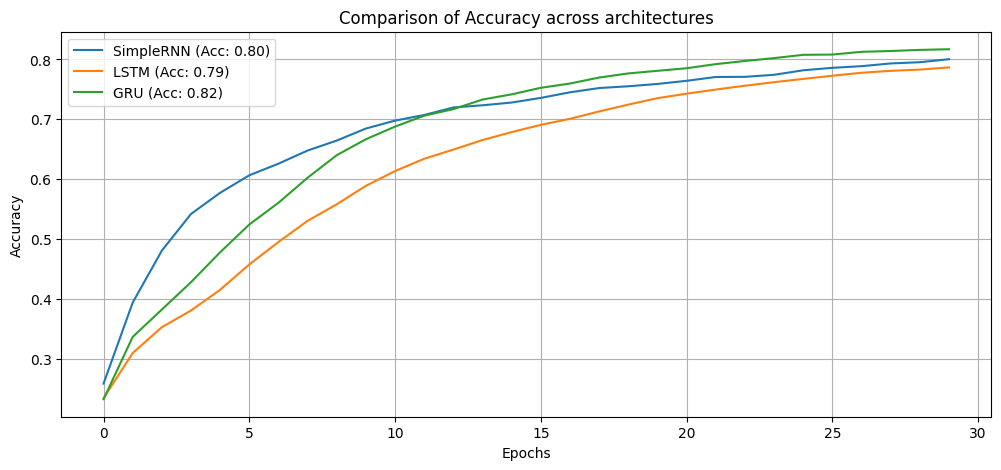

In [21]:
import matplotlib.pyplot as plt

# Visualizing the comparison
plt.figure(figsize=(12, 5))

for name, data in comparison_results.items():
    plt.plot(data['history'].history['accuracy'], label=f'{name} (Acc: {data["final_acc"]:.2f})')

plt.title('Comparison of Accuracy across architectures')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

### Paso 5 — Generación de nombres con semilla

Usamos el modelo con mejor desempeño (GRU) para generar nombres a partir
de una semilla ingresada por el usuario.

Se aplica muestreo con temperatura para controlar la "creatividad" del modelo:
  - Temperatura baja (ej: 0.2): resultados más conservadores y predecibles
  - Temperatura alta (ej: 1.0): resultados más variados pero menos coherentes

El modelo genera letra a letra hasta encontrar el carácter de fin de nombre (\n).

In [29]:
import numpy as  np
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Usamos el modelo GRU que obtuvo el mejor desempeño
modelo_final = comparison_results['GRU']['model']
temperatura = 0.7

def predecir_siguiente_letra(modelo, texto_actual):
    x_indices = [char2idx[c] for c in texto_actual.lower() if c in char2idx]
    x_padded = pad_sequences([x_indices], maxlen=maxlen, padding='pre')
    preds = modelo.predict(x_padded, verbose=0)[0]

    # Muestreo con temperatura
    preds = np.asarray(preds).astype('float64')
    preds = np.log(preds + 1e-7) / temperatura
    exp_preds = np.exp(preds)
    preds = exp_preds / np.sum(exp_preds)

    next_idx = np.random.choice(len(preds), p=preds)
    return idx2char[next_idx]

# Interacción con el usuario
semilla_usuario = input("Escriba una semilla (ej: 'ma'): ")
if semilla_usuario:
    siguiente = predecir_siguiente_letra(modelo_final, semilla_usuario)
    print(f"\nSemilla: '{semilla_usuario}'")
    print(f"Siguiente letra predicha: '{siguiente}'")

    # Generar el resto de la palabra
    nombre_completo = semilla_usuario + siguiente
    print("Generando resto de la palabra...", end=' ')

    for _ in range(20):
        char = predecir_siguiente_letra(modelo_final, nombre_completo)
        if char == '\n' or char == ' ' and len(nombre_completo) > 2: # Stop en fin de línea
            break
        nombre_completo += char

    print(f"\nResultado final: {nombre_completo.strip()}")


Semilla: 'jo'
Siguiente letra predicha: 's'
Generando resto de la palabra... 
Resultado final: jose


### Paso 6 — Evaluación cualitativa: predicción vs. nombre original

Para evaluar la calidad del modelo de forma visual, tomamos 20 nombres
al azar del dataset, extraemos una semilla de 2 a 5 caracteres y dejamos
que el modelo complete el nombre.

Comparamos el resultado generado con el nombre original para observar
qué tan coherentes y similares son las predicciones.

In [35]:
import random

def completar_nombre(modelo, semilla, pasos=15, temperature=0.3):
    resultado = semilla
    for _ in range(pasos):
        # Convertir semilla a secuencia con padding
        x_indices = [char2idx[c] for c in resultado.lower() if c in char2idx]
        x_padded = pad_sequences([x_indices], maxlen=maxlen, padding='pre')

        # Predecir
        preds = modelo.predict(x_padded, verbose=0)[0]

        # Aplicar temperatura para diversidad
        preds = np.asarray(preds).astype('float64')
        preds = np.log(preds + 1e-7) / temperature
        exp_preds = np.exp(preds)
        preds = exp_preds / np.sum(exp_preds)

        next_idx = np.random.choice(len(preds), p=preds)
        next_char = idx2char[next_idx]

        if next_char == '\n':
            break
        resultado += next_char

    return resultado

# Seleccionar 20 nombres aleatorios
nombres_aleatorios = random.sample(nombres, 20)
modelo_uso = comparison_results['GRU']['model']

print(f"{'Nombre Original':<20} | {'Semilla':<10} | {'Predicción Completa'}")
print("-" * 60)

for nombre_original in nombres_aleatorios:
    # Extraer de 2 a 5 caracteres (asegurando no exceder el largo del nombre)
    largo_semilla = random.randint(2, min(5, len(nombre_original)))
    semilla = nombre_original[:largo_semilla]

    # Generar predicción
    prediccion = completar_nombre(modelo_uso, semilla)

    print(f"{nombre_original:<20} | {semilla:<10} | {prediccion}")

Nombre Original      | Semilla    | Predicción Completa
------------------------------------------------------------
samuel               | samue      | samuel
alexander            | alex       | alexander
luis                 | lui        | luis
camilo               | camil      | camilo
isabel               | isabe      | isabel
sofia                | so         | sofia
daniel               | da         | david
maria                | ma         | maria
juan                 | jua        | juan
sofia                | sofi       | sofia
los                  | lo         | lorena
juan                 | ju         | juliana
juan                 | ju         | julian
jose                 | jo         | jose
maria                | maria      | maria
mercedes             | mer        | merina
isaias               | isaia      | isaias
felipe               | fel        | felipe
andrea               | andr       | andres
lucia                | lucia      | lucia


### Paso 7 — Comparación de los tres modelos por temperatura

En este último experimento comparamos cómo responde cada arquitectura
(SimpleRNN, LSTM, GRU) ante distintos valores de temperatura usando
las mismas semillas.

Esto nos permite responder: ¿cambia la calidad de generación según
la arquitectura, o depende principalmente de la temperatura elegida?

In [37]:
import pandas as pd

def comparar_modelos_por_temperatura(seeds, temp):
    results_table = []

    for seed in seeds:
        row = {'Semilla': seed}
        for arch_name, data in comparison_results.items():
            model = data['model']
            # Reutilizamos la lógica de completar_nombre
            prediccion = completar_nombre(model, seed, temperature=temp)
            row[arch_name] = prediccion
        results_table.append(row)

    return pd.DataFrame(results_table)

# Definir variables de entrada
TEST_SEEDS = ['mat', 'jul', 'cat', 'de', 'al']
TEMPERATURA_INPUT = 1 # @param {type:"slider", min:0.1, max:2.0, step:0.1}

print(f"Comparando modelos con Temperatura: {TEMPERATURA_INPUT}")
df_comparativo = comparar_modelos_por_temperatura(TEST_SEEDS, TEMPERATURA_INPUT)
display(df_comparativo)



Comparando modelos con Temperatura: 1


,Semilla,SimpleRNN,LSTM,GRU
0,mat,mateo,mathasia,matiago
1,jul,juliana,julian,juliana
2,cat,catalina,catalia,catilo
3,de,del,del,del
4,al,alcaro,alexando,alberto



# El Problema del Gradiente Desvanecido

El desvanecimiento del gradiente ocurre cuando los gradientes (derivadas parciales de la función de pérdida con respecto a los parámetros del modelo) se vuelven extremadamente pequeños durante el proceso de retropropagación. Esto puede hacer que las actualizaciones de los pesos sean muy pequeñas, lo que ralentiza o incluso detiene el aprendizaje.

En una red neuronal recurrente como SimpleRNN, el problema se amplifica debido a las conexiones recurrentes, donde la información se "pasa" de un paso de tiempo a otro. Los gradientes que se calculan en cada paso hacia atrás pueden disminuir exponencialmente a medida que se retropropagan a través de muchos pasos de tiempo.

## Efectos del desvanecimiento del gradiente en un modelo SimpleRNN:

**Dificultad para aprender dependencias a largo plazo:**

* El SimpleRNN tiene una estructura que hace que los gradientes se desvanecen rápidamente, especialmente si hay muchas capas o pasos de tiempo en la secuencia.

* Esto impide que el modelo aprenda patrones o dependencias que ocurren a largo plazo (por ejemplo, relaciones entre palabras o eventos distantes en el tiempo).

**Entrenamiento lento o estancado:**

* Debido al desvanecimiento del gradiente, el modelo puede experimentar lentitud en el entrenamiento, ya que las actualizaciones de los pesos se hacen muy pequeñas y los pesos no cambian de manera significativa.

* Esto puede llevar a que el modelo se quede atrapado en un mínimo local o simplemente no converja correctamente durante el entrenamiento.

**Desempeño deteriorado:**

* Los modelos con desvanecimiento de gradiente tienden a no generalizar bien, ya que no pueden capturar patrones complejos o dependencias a largo plazo.

* El modelo tiende a predecir de manera mediocre o incluso de manera completamente incorrecta, especialmente en tareas de predicción de secuencias largas o complejas.


<img src="https://github.com/adiacla/RNN/blob/main/desv_gradiente.jpg?raw=true">


## Soluciones al desvanecimiento del gradiente:
Para mitigar el problema del desvanecimiento del gradiente en redes neuronales recurrentes, hay varias estrategias y soluciones que se pueden aplicar:

**Usar LSTM o GRU en lugar de SimpleRNN:**

LSTM (Long Short-Term Memory) y GRU (Gated Recurrent Unit) son variantes de las redes neuronales recurrentes diseñadas específicamente para manejar el problema del desvanecimiento del gradiente. Estas arquitecturas tienen puertas que permiten que las redes recuerden información durante períodos de tiempo más largos sin que los gradientes se desvanezcan.

Las LSTM y GRU son más eficientes para capturar dependencias a largo plazo en secuencias de datos, ya que tienen mecanismos internos que controlan cómo se mantiene y actualiza la memoria a lo largo del tiempo.

**Inicialización adecuada de los pesos:**

Una buena inicialización de los pesos (por ejemplo, usando He initialization o Xavier initialization) puede ayudar a reducir el riesgo de desvanecimiento del gradiente, al asegurar que los gradientes no se vuelvan demasiado pequeños desde el principio.

**Uso de funciones de activación diferentes:**

La función sigmoide y la tangente hiperbólica (tanh) pueden contribuir al desvanecimiento del gradiente. Usar activaciones como ReLU (Rectified Linear Unit) en las capas recurrentes puede ayudar a mitigar este problema, ya que no tienen saturación en la parte positiva, lo que mantiene los gradientes más grandes y estables.

**Técnicas de normalización:**

La normalización de lotes (Batch Normalization) y la normalización de gradientes pueden ayudar a evitar que los gradientes se desvanezcan, aunque estas técnicas son más comunes en redes neuronales tradicionales, no siempre son aplicables directamente a las RNN debido a la naturaleza secuencial de los datos.

**Recorte de gradientes (Gradient Clipping):**

El recorte de gradientes es una técnica en la que se limita el valor de los gradientes si exceden un cierto umbral. Esto no elimina el desvanecimiento del gradiente, pero ayuda a evitar problemas de explosión del gradiente, otro problema relacionado que puede ocurrir en redes profundas.

## <font color="blue">Memoria a Largo y Corto Plazo (Long/Short Term Memory LSTM) </font>

##Arquitecturas Básica  RNN

Los módulos de repetición RNN sencillos tienen una estructura básica con una capa tanh única. La estructura sencilla de la RNN adolece de memoria corta, por lo que le cuesta retener la información de pasos temporales anteriores en datos secuenciales más numerosos.


![](https://miro.medium.com/v2/resize:fit:1170/1*tvIjQjHW-1WGECloYD5efQ.png)

![](https://media.springernature.com/lw685/springer-static/image/art%3A10.1007%2Fs44196-023-00374-8/MediaObjects/44196_2023_374_Fig3_HTML.png?as=webp)

La Long short-term memory (LSTM) es el tipo avanzado de RNN, que se diseñó para evitar tanto los problemas de desvanecimiento como los de explosión de gradiente. Al igual que la RNN, la LSTM tiene módulos que se repiten, pero la estructura es diferente.

En lugar de tener una capa única de tanh, la LSTM tiene cuatro capas que interactúan y se comunican. Esta estructura de cuatro capas ayuda a la LSTM a conservar la memoria a largo plazo y puede utilizarse en varios problemas secuenciales, como la traducción automática, la síntesis del habla, el reconocimiento del habla y el reconocimiento de la escritura a mano. Puedes adquirir experiencia práctica en LSTM siguiendo la guía: LSTM Python para predicciones bursátiles.

Cada una de las tres puertas (entrada, salida y olvido) puede entenderse como una "neurona" artificial convencional, como en una red neuronal multicapa o de propagación hacia adelante (feedforward): es decir, calculan una activación (mediante una función de activación) de una suma ponderada. Intuitivamente, pueden considerarse como reguladores del flujo de valores que atraviesan las conexiones de la LSTM; de ahí la denominación de "puerta". Existen conexiones entre estas puertas y la celda.

La expresión "memoria a largo y corto plazo" se refiere a que LSTM es un modelo para la memoria de corto plazo que puede durar un largo periodo de tiempo. Las LSTM son ideales para clasificar, procesar y predecir series temporales cuando existen desfases temporales de tamaño y duración desconocidos entre eventos importantes. Las LSTM fueron desarrolladas para lidiar con el problema del gradiente desvanecido y el problema del gradiente explosivo al entrenar redes neuronales recurrentes tradicionales.


![adiaz](https://github.com/adiacla/bigdata/blob/master/lstm.JPG?raw=true)



Referencias:

Deep NLP: Redes LSTM (Memoria a Largo y Corto Plazo) con Matemáticas - Medium
[link text](https://https://medium.com/deep-math-machine-learning-ai/chapter-10-1-deepnlp-lstm-long-short-term-memory-networks-with-math-21477f8e4235)



##Componentes de una celda LSTM

La celda LSTM contiene los siguientes componentes:

![imagen](https://substackcdn.com/image/fetch/$s_!c-Qp!,f_auto,q_auto:good,fl_progressive:steep/https%3A%2F%2Fbucketeer-e05bbc84-baa3-437e-9518-adb32be77984.s3.amazonaws.com%2Fpublic%2Fimages%2F1f18455e-0e2e-4c0b-86d4-957f4d5d3d93_1122x497.png)

**Puerta de olvido (f):**
Una red neuronal con activación sigmoide que decide qué parte de la información del estado de memoria anterior debe ser descartada.

**Puerta de entrada (i):**
Una red neuronal con activación sigmoide que determina cuánta información nueva se incorporará al estado de memoria.

**Capa candidata (C̃):**
Una red neuronal con activación tanh que genera nuevos valores candidatos para actualizar el estado de memoria.

**Actualización del estado de memoria (C):**
Se calcula combinando la información retenida (tras pasar por la puerta de olvido) con los nuevos valores candidatos ponderados por la puerta de entrada.

**Puerta de salida (o):**
Una red neuronal con activación sigmoide que controla qué parte del estado de memoria se usará para calcular el estado oculto.

**Estado oculto (h):**
El vector de salida en el paso de tiempo actual, calculado a partir del estado de memoria actualizado y filtrado por la puerta de salida.


###**Entradas de la celda LSTM en cada paso:**

𝑋𝑡: entrada actual

𝐻𝑡−1: estado oculto anterior


𝐶𝑡−1: estado de memoria anterior

**Salidas de la celda LSTM:**

𝐻𝑡: estado oculto actual

𝐶𝑡: estado de memoria actual

Estos componentes trabajan juntos para permitir que la LSTM retenga información relevante a lo largo de pasos de tiempo y olvide aquella que no es útil, facilitando el manejo de dependencias a largo plazo en las secuencias de datos.

## Funcionamiento de las Puertas en una Celda LSTM

**Puerta de Olvido (f):**
Primero, la celda LSTM toma el estado de memoria anterior
𝐶𝑡−1 y lo multiplica, elemento a elemento, por el valor de la puerta de olvido (f) para decidir el estado de memoria actual
𝐶𝑡. La puerta de olvido tiene valores entre 0 y 1:
Si el valor de la puerta de olvido es 0, el estado de memoria anterior se olvida completamente.
Si el valor de la puerta de olvido es 1, el estado de memoria anterior se conserva por completo en la celda.
Esto permite que la celda decida cuánta información del pasado debe mantener o descartar.




**C<sub>t</sub> = C<sub>t-1</sub> * f<sub>t</sub>**

Cálculo del Nuevo Estado de Memoria:

**C<sub>t</sub> = C<sub>t</sub> + (I<sub>t</sub> * C\`<sub>t</sub>)**


Ahora, calculamos la salida:

**H<sub>t</sub> = tanh(C<sub>t</sub>)**




# <font color="green"> Ejemplo 2: Construcción de palabras en secuencia usando LSTM</font>

Fuente de texto: Alicia en el país de las maravillas

Objetivo: Entrenar una red neuronal recurrente (RNN) para generar texto similar al estilo del libro original, pero usando usando Simple, LSTM y GRU

## Lectura del Archivo:

Se obtiene el contenido del archivo de texto desde la URL proporcionada. El texto se normaliza eliminando espacios y convirtiendo a minúsculas.


In [1]:
import requests
import numpy as np
import re
import unicodedata
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

## 1. Descarga y Limpieza (Nivel Palabras

Este Script se encarga de descargar y limpiar un texto, para luego contar las palabras. Primero, descarga un archivo de texto desde del github, del libro en españo 'Alicia en el País de las Maravillas'. Luego, define una función llamada limpiar_texto que elimina acentos, caracteres especiales (manteniendo solo letras y espacios), y convierte todo a minúsculas. Finalmente, aplica esta función al texto descargado, lo divide en palabras y muestra el número total de palabras obtenidas

In [2]:
# =========================================================
# 1. DESCARGA Y LIMPIEZA DE MÚLTIPLES TEXTOS
# =========================================================

# Lista de libros en español para enriquecer el vocabulario
urls = [
    "https://github.com/adiacla/RNN/raw/refs/heads/main/APMaravillas.txt", # Alicia
    "https://raw.githubusercontent.com/adiacla/bigdata/refs/heads/master/donquijote.txt",                # Don Quijote (Fragmentos/Parte 1)
    "https://raw.githubusercontent.com/adiacla/bigdata/refs/heads/master/novelas.txt"               # El buscón (Quevedo)
]

def limpiar_texto(texto):
    # Normalizar para eliminar acentos
    texto = unicodedata.normalize('NFKD', texto)
    texto = ''.join(c for c in texto if not unicodedata.combining(c))
    # Mantener solo letras y espacios, quitar números y símbolos
    texto = re.sub(r'[^a-zA-Z\s]', '', texto)
    return texto.lower().strip()

print("Descargando y procesando textos...")
texto_total = ""
for url in urls:
    try:
        r = requests.get(url)
        r.encoding = 'utf-8'
        texto_total += r.text + " "
    except:
        print(f"No se pudo descargar: {url}")

texto_limpio = limpiar_texto(texto_total)
palabras = texto_limpio.split()
print(f"Total de palabras en el dataset: {len(palabras)}")

Descargando y procesando textos...
Total de palabras en el dataset: 462572


## Procesamiento del Texto:

Se divide el texto en líneas y se eliminan las líneas vacías. Es decir se realiza la tokenización de una lista de palabras, que es un paso crucial en el preprocesamiento de texto para modelos de redes neuronales. Primero, se inicializa un objeto Tokenizer de Keras. Luego, este tokenizer aprende el vocabulario único presente en la lista de palabras que se le proporciona. Después, convierte esta lista de palabras en una secuencia de números enteros, donde cada palabra se reemplaza por su índice numérico correspondiente en el vocabulario. Finalmente, calcula el tamaño total del vocabulario, sumando 1 al número de palabras únicas para incluir el índice 0, que se reserva comúnmente para el 'padding' (relleno) en secuencias de longitud variable.

In [3]:
# =========================================================
# 2. TOKENIZACIÓN (NIVEL PALABRA)2
# =========================================================
tokenizer = Tokenizer()
tokenizer.fit_on_texts([palabras])
encoded = tokenizer.texts_to_sequences([palabras])[0]
vocab_size = len(tokenizer.word_index) + 1

print(f"Tamaño del vocabulario único: {vocab_size}")


Tamaño del vocabulario único: 29038


In [4]:
for word, index in list(tokenizer.word_index.items())[:20]:
    print(f"{index}: {word}")

1: que
2: de
3: y
4: la
5: a
6: el
7: en
8: no
9: se
10: los
11: con
12: por
13: las
14: lo
15: su
16: le
17: del
18: como
19: don
20: me


In [5]:
tokenizer.word_index

{'que': 1,
 'de': 2,
 'y': 3,
 'la': 4,
 'a': 5,
 'el': 6,
 'en': 7,
 'no': 8,
 'se': 9,
 'los': 10,
 'con': 11,
 'por': 12,
 'las': 13,
 'lo': 14,
 'su': 15,
 'le': 16,
 'del': 17,
 'como': 18,
 'don': 19,
 'me': 20,
 'mas': 21,
 'si': 22,
 'un': 23,
 'es': 24,
 'mi': 25,
 'al': 26,
 'quijote': 27,
 'yo': 28,
 'sancho': 29,
 'dijo': 30,
 'para': 31,
 'una': 32,
 'ni': 33,
 'porque': 34,
 'tan': 35,
 'o': 36,
 'todo': 37,
 'sus': 38,
 'esta': 39,
 'sin': 40,
 'pero': 41,
 'ser': 42,
 'asi': 43,
 'bien': 44,
 'ha': 45,
 'senor': 46,
 'habia': 47,
 'respondio': 48,
 'pues': 49,
 'esto': 50,
 'este': 51,
 'ya': 52,
 'quien': 53,
 'cuando': 54,
 'todos': 55,
 'era': 56,
 'merced': 57,
 'vuestra': 58,
 'donde': 59,
 'te': 60,
 'dos': 61,
 'cual': 62,
 'tu': 63,
 'sino': 64,
 'fue': 65,
 'ella': 66,
 'muy': 67,
 'caballero': 68,
 'decir': 69,
 'aquel': 70,
 'he': 71,
 'otra': 72,
 'otro': 73,
 'hacer': 74,
 'estaba': 75,
 'aunque': 76,
 'dios': 77,
 'aqui': 78,
 'son': 79,
 'sobre': 80,
 'ta

In [6]:
print("Número total de tokens:", len(encoded))
print("Ejemplo de tokens:", encoded[:20])


Número total de tokens: 462572
Ejemplo de tokens: [10244, 8025, 99, 7, 6, 4907, 2, 13, 1202, 10244, 8025, 3935, 17, 113, 8026, 1, 65, 56, 14956, 14957]


In [12]:
# =========================================================
# 3. CREACIÓN DE SECUENCIAS CON PADDING DINÁMICO
# =========================================================
# SEQLEN es el tamaño máximo de la ventana de memoria
SEQLEN = 15
X = []
y = []

print("Creando secuencias de entrenamiento...")
# Generamos secuencias incrementales para que el modelo aprenda a usar el PADDING
# Si el texto es "el conejo blanco", generamos:
# [0, 0, el] -> conejo
# [0, el, conejo] -> blanco
for i in range(1, len(encoded)):
    # Tomamos el trozo de historia hasta la palabra i
    secuencia_actual = encoded[max(0, i - SEQLEN):i]
    X.append(secuencia_actual)
    y.append(encoded[i])

# Aplicamos PADDING frontal (pre) para igualar todas las secuencias a SEQLEN
X = pad_sequences(X, maxlen=SEQLEN, padding='pre')
y = np.array(y)

print(f"Forma final de los datos (X): {X.shape}")


Creando secuencias de entrenamiento...
Forma final de los datos (X): (462571, 15)


In [13]:
print(X.shape)  # (num_samples, SEQLEN)
print(y.shape)  # (num_samples,)


(462571, 15)
(462571,)


In [14]:
X[1000]

array([  109,     2, 10271,     7,    13,  3943,     2,     4,  2000,
           3,    76,     8,    56,    23,   732], dtype=int32)

In [15]:
y[1000]

np.int64(67)

## Entrenamiento del Modelo:

El modelo se entrena varias veces (definido por NUM_ITERATIONS), lo que permite que aprenda mejor las relaciones en los datos.

En cada iteración, el modelo se ajusta a los datos de entrada X y las etiquetas y durante un número específico de épocas (NUM_EPOCHS_PER_ITERATION).



In [11]:
def crear_modelo_avanzado():
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=128, mask_zero=True),
        LSTM(256, return_sequences=False, use_cudnn=False),
        Dropout(0.3),
        Dense(vocab_size, activation='softmax')
    ])

    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

modelo = crear_modelo_avanzado()
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# =========================================================
# 5. ENTRENAMIENTO CON CALLBACKS
# =========================================================
# Detener el entrenamiento si el modelo deja de aprender
callbacks = [
    EarlyStopping(monitor='loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='loss', factor=0.2, patience=3)
]

print("\nIniciando entrenamiento...")
history = modelo.fit(
    X, y,
    epochs=50, # Puedes subirlo a 100 para mejores resultados
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)


Iniciando entrenamiento...
Epoch 1/50
3614/3614 ━━━━━━━━━━━━━━━━━━━━ 44s 11ms/step - accuracy: 0.0826 - loss: 6.5498 - learning_rate: 0.0010
Epoch 2/50
3614/3614 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - accuracy: 0.1243 - loss: 5.9235 - learning_rate: 0.0010
Epoch 3/50
3614/3614 ━━━━━━━━━━━━━━━━━━━━ 36s 10ms/step - accuracy: 0.1463 - loss: 5.5782 - learning_rate: 0.0010
Epoch 4/50
3614/3614 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - accuracy: 0.1615 - loss: 5.2994 - learning_rate: 0.0010
Epoch 5/50
3614/3614 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - accuracy: 0.1739 - loss: 5.0572 - learning_rate: 0.0010
Epoch 6/50
3614/3614 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - accuracy: 0.1867 - loss: 4.8353 - learning_rate: 0.0010
Epoch 7/50
3614/3614 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - accuracy: 0.1995 - loss: 4.6230 - learning_rate: 0.0010
Epoch 8/50
3614/3614 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - accuracy: 0.2147 - loss: 4.4168 - learning_rate: 0.0010
Epoch 9/50
3614/3614 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - ac

In [ ]:
# =========================================================
# 6. FUNCIÓN DE PREDICCIÓN (CON PADDING Y TEMPERATURA)
# =========================================================
def generar_texto(seed_text, words_to_predict, model, tokenizer, SEQLEN, temperature=1.0):
    result_words = seed_text.lower().split()

    for _ in range(words_to_predict):
        # Convertir palabras actuales a números
        encoded_input = tokenizer.texts_to_sequences([result_words])[0]

        # Ajustar longitud al SEQLEN (Padding frontal automático)
        padded_input = pad_sequences([encoded_input], maxlen=SEQLEN, padding='pre')

        # Predicción de probabilidades
        preds = model.predict(padded_input, verbose=0)[0]

        # Aplicar temperatura (creatividad)
        preds = np.asarray(preds).astype('float64')
        preds = np.log(preds + 1e-8) / temperature
        exp_preds = np.exp(preds)
        preds = exp_preds / np.sum(exp_preds)

        # Seleccionar la siguiente palabra
        next_index = np.random.choice(len(preds), p=preds)
        next_word = tokenizer.index_word.get(next_index, "")

        if not next_word: break

        result_words.append(next_word)

    return ' '.join(result_words)

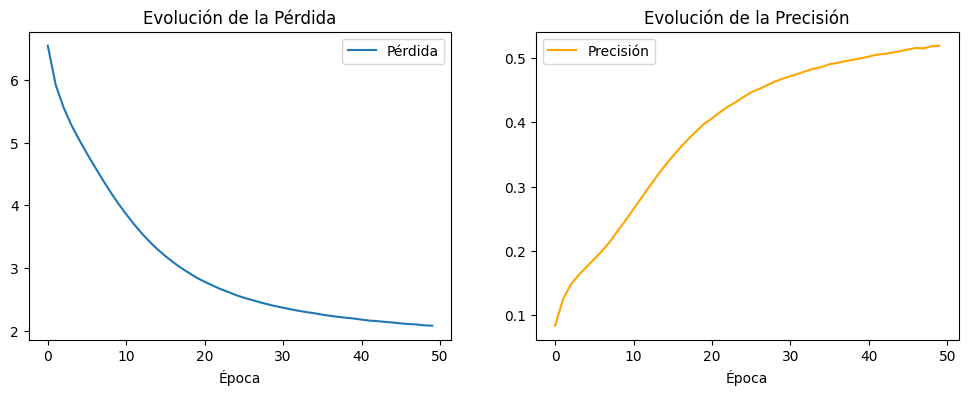

In [ ]:
# =========================================================
# 7. GRAFICAR RESULTADOS
# =========================================================
def plot_results(history):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Pérdida')
    plt.title('Evolución de la Pérdida')
    plt.xlabel('Época')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Precisión', color='orange')
    plt.title('Evolución de la Precisión')
    plt.xlabel('Época')
    plt.legend()

    plt.show()

plot_results(history)

In [ ]:
# =========================================================
# 8. PRUEBAS DE GENERACIÓN
# =========================================================
print("\n--- PRUEBA 1: SEMILLA CORTA ---")
print(generar_texto("estoy jugando a ser celador", 20, modelo, tokenizer, SEQLEN, temperature=0.7))

print("\n--- PRUEBA 2: ESTILO CLÁSICO ---")
print(generar_texto("Estoy contigo", 20, modelo, tokenizer, SEQLEN, temperature=0.6))


--- PRUEBA 1: SEMILLA CORTA ---
alicia estaba en el balcon lo que no haba una idea como de persona y as pues el lirn y no se atrevi a acercarse

--- PRUEBA 2: ESTILO CLÁSICO ---
esto lo que pasó cuando el le mandaba y se veian con la ventera que don quijote le decia y que le pedia no queria que


# <font color="green">Ejercicio con Serie de tiempo para precio de las acciones
Modelo de predicción de precios de acciones utilizando una red neuronal recurrente (RNN), específicamente una LSTM (Long Short-Term Memory). }

Este modelo tiene como objetivo predecir el precio de las acciones de Tesla basándose en datos históricos.

 A continuación explico paso a paso qué hace cada parte del código:

In [ ]:
! pip list | grep "yfinance"

#!pip install yfinance

# 1. Importación de bibliotecas:
Se importan varias bibliotecas esenciales para el procesamiento de datos (numpy, pandas), gráficos (matplotlib, plotly), preprocesamiento de datos (MinMaxScaler de sklearn), y para la creación y entrenamiento del modelo (keras).



In [ ]:
# Importando las bibliotecas
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout
from sklearn.metrics import mean_squared_error
import math



# 2. Descarga de los datos históricos de Tesla:
Utiliza la API de Yahoo Finance (yfinance) para descargar los precios históricos de las acciones de Tesla desde enero de 2023 hasta la fecha actual (noviembre de 2024).
Los datos descargados incluyen precios de apertura, cierre, máximo, mínimo, volumen de transacciones, etc. Se guarda en un DataFrame de pandas.

(https://finance.yahoo.com/quote/TSLA/)


In [ ]:
import yfinance as yf

# Descargar los datos históricos de las acciones de Tesla
tesla = yf.Ticker('TSLA')

# Obtener los precios históricos para el periodo desde 2023 hasta la fecha actual
dataset = tesla.history(start="2025-01-01")  # Ajustar la fecha de fin a la actual

dataset[-20:]



,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-04-15 00:00:00-04:00,366.829987,394.649994,362.500000,391.950012,113810400,0.0,0.0
2026-04-16 00:00:00-04:00,393.809998,394.059998,381.799988,388.899994,63515100,0.0,0.0
2026-04-17 00:00:00-04:00,395.920013,409.279999,391.649994,400.619995,90640000,0.0,0.0
2026-04-20 00:00:00-04:00,402.579987,406.799988,388.329987,392.500000,64603900,0.0,0.0
2026-04-21 00:00:00-04:00,393.000000,393.950012,385.220001,386.420013,50530600,0.0,0.0
2026-04-22 00:00:00-04:00,387.570007,393.010010,385.299988,387.510010,62362800,0.0,0.0
2026-04-23 00:00:00-04:00,375.279999,386.000000,368.390015,373.720001,93969500,0.0,0.0
2026-04-24 00:00:00-04:00,373.500000,382.760010,370.730011,376.299988,62893300,0.0,0.0
2026-04-27 00:00:00-04:00,372.089996,380.779999,364.019989,378.670013,66735800,0.0,0.0


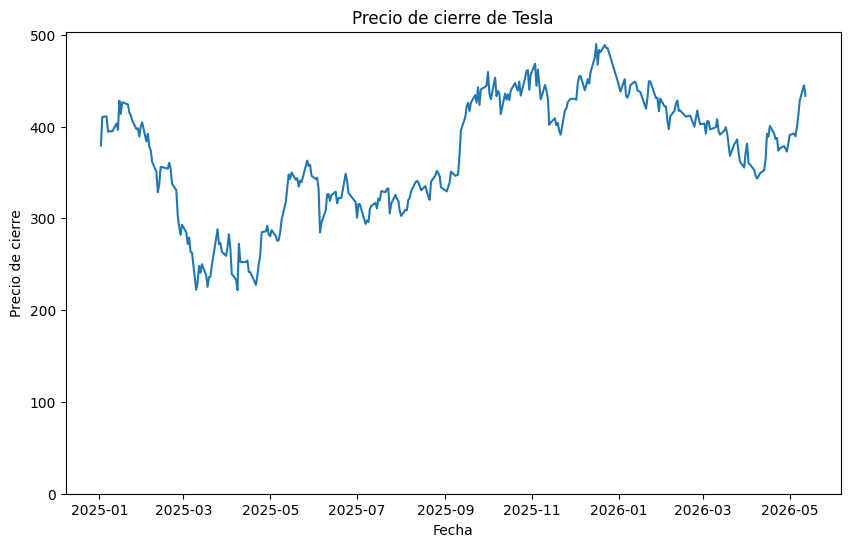

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(dataset['Close'])
plt.title('Precio de cierre de Tesla')
plt.xlabel('Fecha')
plt.ylabel('Precio de cierre')

# Set y-axis limits
plt.ylim(0)
plt.show()


In [ ]:

# También puedes guardar los datos en un archivo CSV si lo deseas
dataset.to_csv('tesla_stock_data.csv')

In [ ]:

dataset.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-01-02 00:00:00-05:00,390.100006,392.730011,373.040009,379.279999,109710700,0.0,0.0
2025-01-03 00:00:00-05:00,381.480011,411.880005,379.450012,410.440002,95423300,0.0,0.0
2025-01-06 00:00:00-05:00,423.200012,426.429993,401.700012,411.049988,85516500,0.0,0.0
2025-01-07 00:00:00-05:00,405.829987,414.329987,390.000000,394.359985,75699500,0.0,0.0
2025-01-08 00:00:00-05:00,392.950012,402.500000,387.399994,394.940002,73038800,0.0,0.0


In [ ]:
dataset[:'2025']

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-01-02 00:00:00-05:00,390.100006,392.730011,373.040009,379.279999,109710700,0.0,0.0
2025-01-03 00:00:00-05:00,381.480011,411.880005,379.450012,410.440002,95423300,0.0,0.0
2025-01-06 00:00:00-05:00,423.200012,426.429993,401.700012,411.049988,85516500,0.0,0.0
2025-01-07 00:00:00-05:00,405.829987,414.329987,390.000000,394.359985,75699500,0.0,0.0
2025-01-08 00:00:00-05:00,392.950012,402.500000,387.399994,394.940002,73038800,0.0,0.0
...,...,...,...,...,...,...,...
2025-12-24 00:00:00-05:00,488.480011,490.899994,476.799988,485.399994,41285400,0.0,0.0
2025-12-26 00:00:00-05:00,485.230011,489.089996,473.820007,475.190002,58780700,0.0,0.0
2025-12-29 00:00:00-05:00,469.000000,469.399994,459.000000,459.640015,66263000,0.0,0.0


# 3. Preprocesamiento de los datos:
Se separan los datos en dos conjuntos:
Conjunto de entrenamiento: Los datos anteriores a 2023.
Conjunto de prueba: Los datos de 2024 en adelante.
Se selecciona la columna de precios "High" (el precio más alto del día) para predecir el comportamiento de los precios.

In [ ]:
# Usar columna 'Close' para precios de cierre
# Usamos la columna 'Close'
prices = dataset['Close'].values.reshape(-1, 1)


In [ ]:
prices.shape

(340, 1)

In [ ]:
# Dividir la serie temporal en conjuntos de entrenamiento y prueba.
# Se mantiene el orden cronológico: el 80% de los datos más antiguos se usan para entrenamiento,
# y el 20% más recientes se reservan para la evaluación como conjunto de prueba.
training_set = prices
print(f'Tamaño del conjunto de entrenamiento (datos históricos): {len(training_set)}')
print(f'Tamaño del conjunto de prueba (datos más recientes): {len(test_set)}')

Tamaño del conjunto de entrenamiento (datos históricos): 340
Tamaño del conjunto de prueba (datos más recientes): 68


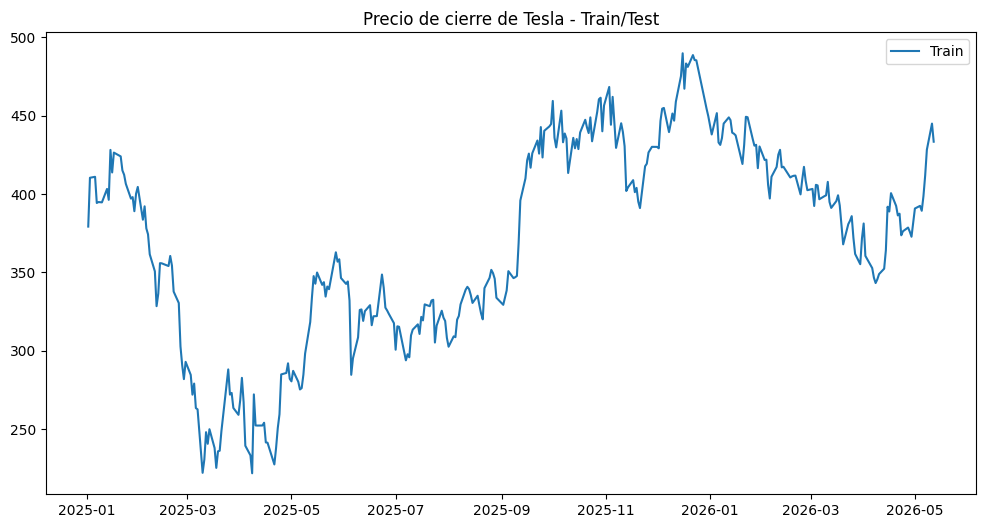

In [ ]:
# Graficar precios de cierre
plt.figure(figsize=(12,6))
plt.plot(dataset.index, training_set, label='Train')
plt.title('Precio de cierre de Tesla - Train/Test')
plt.legend()
plt.show()

In [ ]:
import plotly.graph_objects as go

# Crear un gráfico de velas (candlestick chart)
fig = go.Figure(data=[go.Candlestick(
    x=dataset.index,
    open=dataset['Open'],
    high=dataset['High'],
    low=dataset['Low'],
    close=dataset['Close'],
    increasing_line_color='green', decreasing_line_color='red',  # Colores para las velas
)])

# Agregar título y etiquetas
fig.update_layout(
    title='Tesla Stock Price (2025- a la fecha)',
    xaxis_title='Fecha',
    yaxis_title='Precio de la acción (USD)',
    xaxis_rangeslider_visible=False  # Opcional: desactiva el control deslizante en el gráfico
)

# Mostrar el gráfico
fig.show()

Luego, los precios son normalizados (escalados) para que los valores estén entre 0 y 1 utilizando MinMaxScaler. Esto es importante para mejorar la eficiencia y el rendimiento del modelo de redes neuronales.

In [ ]:
# Escalando el conjunto de entrenamiento
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
training_set_scaled = scaler.fit_transform(training_set)

In [ ]:
print(training_set_scaled.shape)


(340, 1)


# 4. Creación de la estructura de datos para el modelo:
La red LSTM necesita una secuencia de entradas para aprender de los patrones temporales. Por ello, se crean secuencias de 20 días de precios pasados (20 pasos de tiempo) y el precio de cierre correspondiente para cada secuencia.
Esto se hace en el bloque de código siguiente, donde se construye la entrada X_train y la salida y_train.


In [ ]:
# Dado que los LSTM almacenan el estado de memoria a largo plazo, creamos una estructura de datos con 30 pasos de tiempo y 1 salida
# Así que, para cada elemento del conjunto de entrenamiento, tenemos 20 elementos previos del conjunto de entrenamiento
import numpy as np
SEQLEN = 20  # Usar 20 días para predecir el siguiente, como se sugirió.

X_train, y_train = [], []
for i in range(SEQLEN, len(training_set_scaled)):
    X_train.append(training_set_scaled[i-SEQLEN:i, 0])
    y_train.append(training_set_scaled[i, 0])

X_train, y_train = np.array(X_train), np.array(y_train)

In [ ]:
X_train[1]

array([0.7036042 , 0.7058801 , 0.64360862, 0.6457727 , 0.64502644,
       0.67700169, 0.65107075, 0.76994253, 0.71621522, 0.7635251 ,
       0.75445864, 0.72102821, 0.71084248, 0.68920223, 0.65401832,
       0.65752553, 0.6239833 , 0.66569657, 0.6818148 , 0.60376087])

In [ ]:
y_train[1]

np.float64(0.7162152214531217)

Finalmente, X_train se reorganiza en una forma adecuada para la entrada de la red neuronal LSTM, que requiere una estructura de tres dimensiones (muestras, pasos de tiempo, características).

In [ ]:
# Suponiendo que X_train tiene forma (n_samples, timesteps)
# Reshape para LSTM: (samples, time_steps, features)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [ ]:
X_train

array([[[0.58734421],
        [0.7036042 ],
        [0.7058801 ],
        ...,
        [0.6239833 ],
        [0.66569657],
        [0.6818148 ]],

       [[0.7036042 ],
        [0.7058801 ],
        [0.64360862],
        ...,
        [0.66569657],
        [0.6818148 ],
        [0.60376087]],

       [[0.7058801 ],
        [0.64360862],
        [0.6457727 ],
        ...,
        [0.6818148 ],
        [0.60376087],
        [0.63558685]],

       ...,

       [[0.47418107],
        [0.48712787],
        [0.5310798 ],
        ...,
        [0.62499064],
        [0.65991347],
        [0.70864116]],

       [[0.48712787],
        [0.5310798 ],
        [0.63461685],
        ...,
        [0.65991347],
        [0.70864116],
        [0.77042759]],

       [[0.5310798 ],
        [0.63461685],
        [0.62323704],
        ...,
        [0.70864116],
        [0.77042759],
        [0.83254979]]])

# 5. Construcción del modelo LSTM:
Se define un modelo de red neuronal secuencial con capas LSTM. Las redes LSTM son ideales para datos secuenciales como los precios de acciones, ya que pueden recordar información de pasos anteriores.
Se agregan 4 capas LSTM con regularización de Dropout para evitar el sobreajuste, y finalmente, una capa densa para obtener la salida (predicción del precio).

El modelo se compila utilizando el optimizador RMSprop y la función de pérdida

In [ ]:
from tensorflow.keras.layers import Input


model = Sequential([
    Input(shape=(SEQLEN, 1)),  # Aquí defines la forma de entrada explícitamente
    LSTM(units=50, return_sequences=True),
    Dropout(0.2),
    LSTM(units=50),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 20, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 20, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

# 6. Entrenamiento del modelo:
El modelo se entrena utilizando el método .fit(), lo que ajusta el modelo a los datos de entrenamiento (X_train y y_train).
También se emplea un división de validación durante el entrenamiento (20%) para monitorear el rendimiento del modelo en datos no vistos mientras se entrena.

In [ ]:
# Separar los últimos N días del entrenamiento como validación (por ejemplo, 20%)
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.2535 - val_loss: 0.0149
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0416 - val_loss: 0.0091
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0247 - val_loss: 0.0234
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0218 - val_loss: 0.0081
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0156 - val_loss: 0.0078
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0153 - val_loss: 0.0096
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0130 - val_loss: 0.0078
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0102 - val_loss: 0.0083
Epoch 9/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0120 - val_loss: 0.0077
Epoch 10/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0118 - val_loss: 0.0089
Epoch 11/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0123 - val_loss: 0.0085
Epoch 12/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0116 - val_loss: 0.0076
E

# 7. Graficar el history del entrenamiento:
Después de entrenar el modelo, se grafican las curvas de pérdida (loss) tanto para los datos de entrenamiento como para los de validación. Esto ayuda a ver si el modelo está aprendiendo de manera efectiva o si está sobreajustando los datos.
python
Copiar código


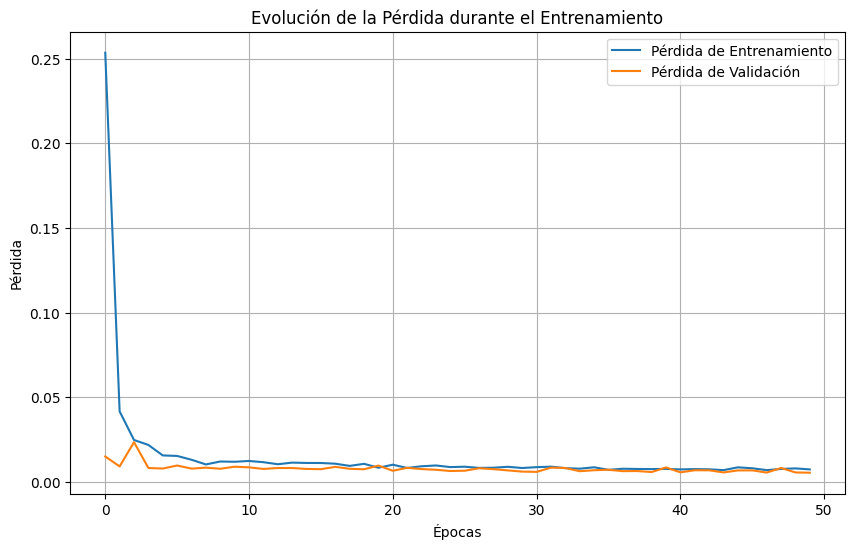

In [ ]:
# Graficar el history de la pérdida de entrenamiento y validación
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Pérdida de Entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de Validación')
plt.title('Evolución de la Pérdida durante el Entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#La predicción de todos los precios de acuerdo a cada ventana de X
predicted_prices = model.predict(X_train)
predicted_prices = scaler.inverse_transform(predicted_prices)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step  


**8. Gráficos adicionales:**
Se incluyen gráficos para visualizar los precios históricos de las acciones de Tesla, tanto para el conjunto de entrenamiento como para el conjunto de prueba, antes y después de 2025.
También, se muestra un gráfico tipo candlestick utilizando Plotly para visualizar los precios abiertos, cerrados, altos y bajos de las acciones de Tesla.

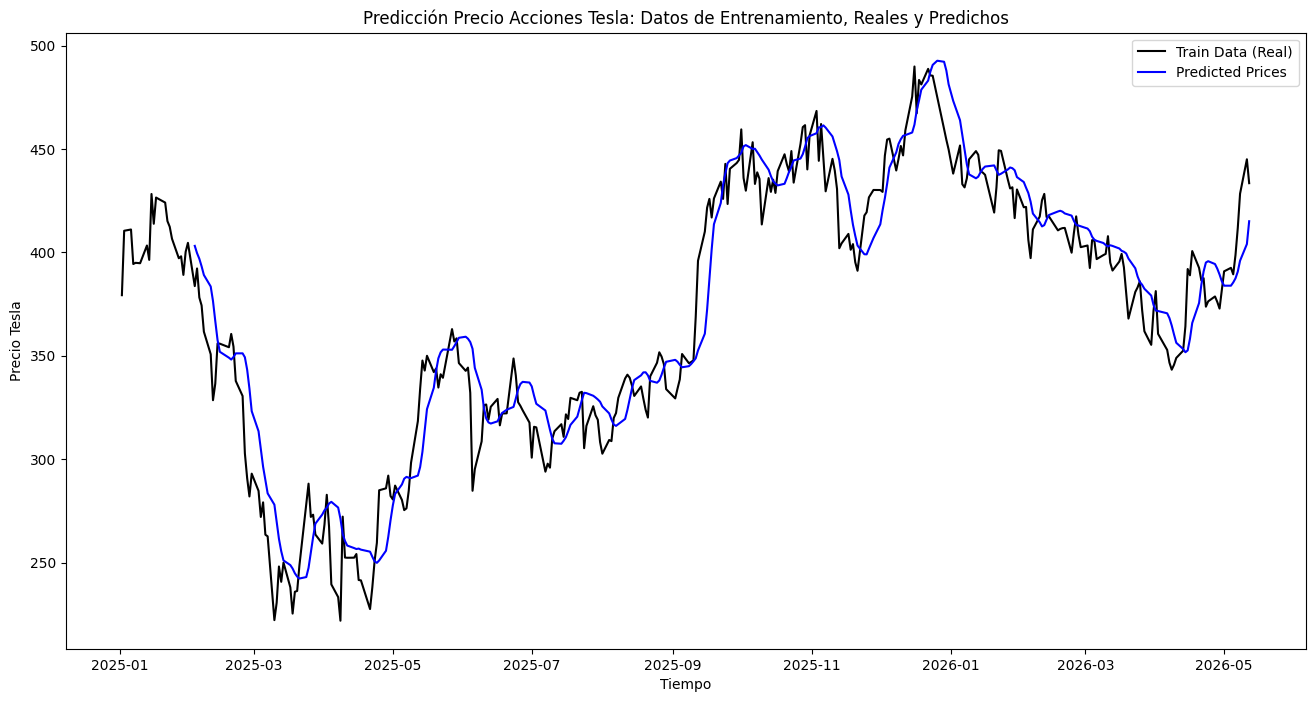

RMSE: 18.97754758534705


In [ ]:
plt.figure(figsize=(16,8))
plt.plot(dataset.index, training_set, color='black', label='Train Data (Real)')
# Plot predicted prices against the corresponding time steps
plt.plot(dataset.index[SEQLEN:], predicted_prices, color='blue', label='Predicted Prices')
plt.title('Predicción Precio Acciones Tesla: Datos de Entrenamiento, Reales y Predichos')
plt.xlabel('Tiempo')
plt.ylabel('Precio Tesla')
plt.legend()
plt.show()

# Calcular RMSE
# predicted_prices correspond to the actual values starting from SEQLEN in the original training_set
rmse = math.sqrt(mean_squared_error(training_set[SEQLEN:], predicted_prices))
print(f'RMSE: {rmse}')

In [ ]:
import numpy as np

# Suponiendo que test_set es un array 2D con forma (num_muestras, 1)
last_days = dataset['Close'][-SEQLEN:].values  # últimos SEQLEN precios reales

# Normalizamos esos últimos días igual que entrenamiento
last_days_scaled = scaler.transform(last_days.reshape(-1,1))

predictions_scaled = []

# Pre-allocate the input sequence array and populate it with the initial window
# Shape will be (1, SEQLEN, 1)
current_input_sequence = np.array(last_days_scaled.reshape(1, SEQLEN, 1), dtype=np.float32)

for _ in range(10):  # predecir 10 días futuros
    # Predict using the current input sequence
    pred = model.predict(current_input_sequence)[0,0]
    predictions_scaled.append(pred)

    # Update the input sequence by shifting elements and adding the new prediction
    # This avoids recreating the entire array with np.append
    current_input_sequence[0, :-1, 0] = current_input_sequence[0, 1:, 0] # Shift left
    current_input_sequence[0, -1, 0] = pred # Add new prediction at the end

# Volver a escala original
predictions = scaler.inverse_transform(np.array(predictions_scaled).reshape(-1,1))

print("Predicciones para los próximos 10 días:")
print(predictions.flatten())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Predicciones para los próximos 10 días:
[425.1013  432.16537 437.40033 441.4283  444.69183 447.47385 449.94125
 452.22583 454.38083 456.44345]


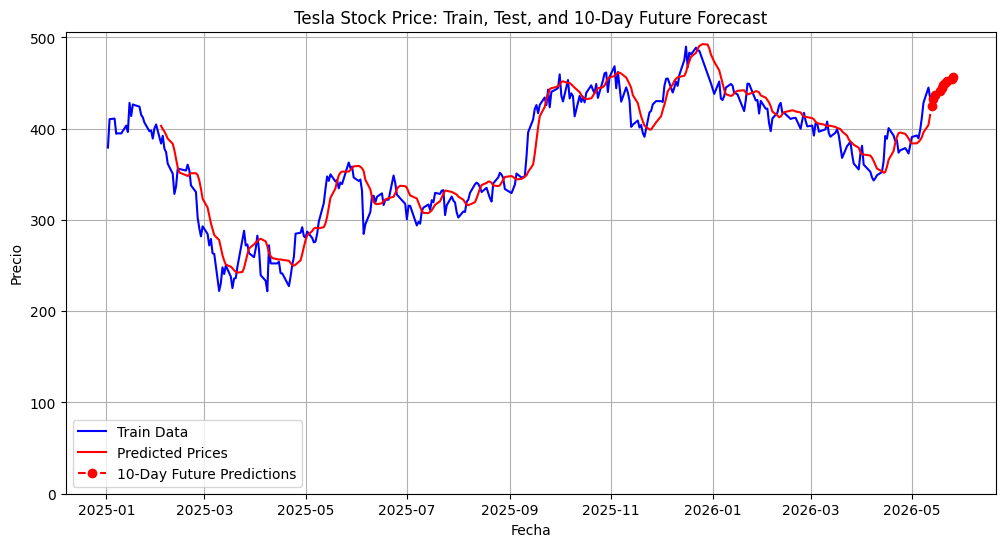

In [ ]:
import pandas as pd

# Grafique los datos de entrenamiento y las 10 predicciones y grafiquelas
plt.figure(figsize=(12,6))
plt.plot(dataset.index, training_set, color='blue', label='Train Data')
plt.plot(dataset.index[SEQLEN:], predicted_prices, color='red', label='Predicted Prices')
# Generar fechas para las 10 predicciones futuras
last_date = dataset.index[-1]
future_dates_10 = pd.bdate_range(start=last_date, periods=11, freq='B')[1:] # 10 future dates

# Plot the 10-day predictions
plt.plot(future_dates_10, predictions.flatten(), color='red', linestyle='--', marker='o', label='10-Day Future Predictions')

plt.title('Tesla Stock Price: Train, Test, and 10-Day Future Forecast')
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0) # Ensure y-axis starts at 0
plt.show()

### Ahora, vamos a entrenar y evaluar un modelo GRU para comparar su rendimiento con el LSTM.

In [ ]:
from tensorflow.keras.layers import GRU

def crear_modelo_gru():
    model_gru = Sequential([
        Input(shape=(SEQLEN, 1)),
        GRU(units=50, return_sequences=True),
        Dropout(0.2),
        GRU(units=50),
        Dropout(0.2),
        Dense(1)
    ])

    model_gru.compile(optimizer='adam', loss='mean_squared_error')
    return model_gru

model_gru = crear_modelo_gru()
model_gru.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_4 (GRU)                     │ (None, 20, 50)         │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 20, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,301 (91.02 KB)

 Trainable params: 23,301 (91.02 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print("Entrenando el modelo GRU...")
history_gru = model_gru.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

Entrenando el modelo GRU...
Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0728 - val_loss: 0.0230
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0254 - val_loss: 0.0078
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0170 - val_loss: 0.0094
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0127 - val_loss: 0.0050
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0103 - val_loss: 0.0052
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0093 - val_loss: 0.0050
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0082 - val_loss: 0.0050
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0085 - val_loss: 0.0044
Epoch 9/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0078 - val_loss: 0.0063
Epoch 10/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0077 - val_loss: 0.0042
Epoch 11/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0081 - val_loss: 0.0059
Epoch 12/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss:

#### Visualización de la pérdida del modelo GRU

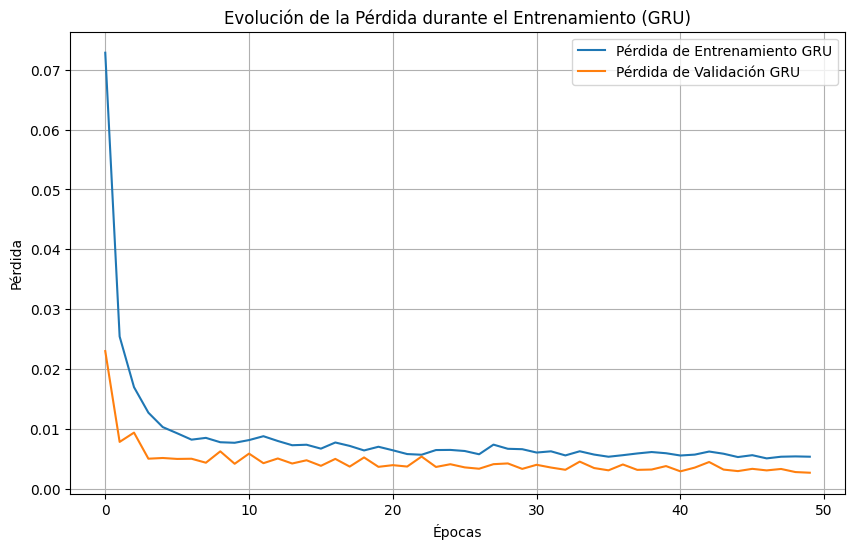

In [ ]:
# Graficar el history de la pérdida de entrenamiento y validación para el modelo GRU
plt.figure(figsize=(10,6))
plt.plot(history_gru.history['loss'], label='Pérdida de Entrenamiento GRU')
plt.plot(history_gru.history['val_loss'], label='Pérdida de Validación GRU')
plt.title('Evolución de la Pérdida durante el Entrenamiento (GRU)')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)
plt.show()

#### Calculando RMSE para el modelo GRU

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
RMSE del modelo GRU: 14.395855610765937
RMSE del modelo LSTM: 18.97754758534705


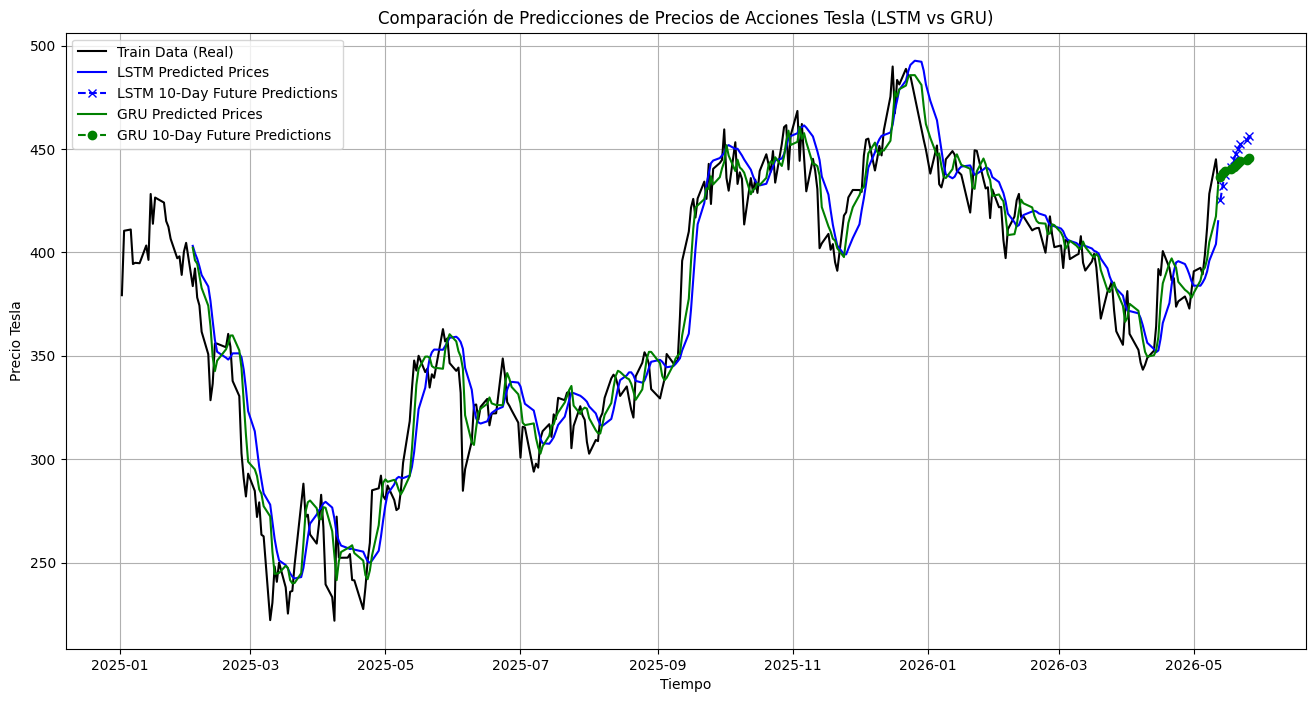

In [ ]:
# Predecir con el modelo GRU en el conjunto de entrenamiento
predicted_prices_gru = model_gru.predict(X_train)
predicted_prices_gru = scaler.inverse_transform(predicted_prices_gru)

# Calcular RMSE para el modelo GRU
rmse_gru = math.sqrt(mean_squared_error(training_set[SEQLEN:], predicted_prices_gru))
print(f'RMSE del modelo GRU: {rmse_gru}')
print(f'RMSE del modelo LSTM: {rmse}')

# Generar fechas para las 10 predicciones futuras del GRU
last_date = dataset.index[-1]
future_dates_10_gru = pd.bdate_range(start=last_date, periods=11, freq='B')[1:] # 10 future dates

# Obtener las predicciones futuras del modelo GRU (usando el código existente)
# 'predictions' variable from cell UP2f4ZFiwD6s was for LSTM, let's regenerate GRU future predictions.

last_days_gru = dataset['Close'][-SEQLEN:].values
last_days_scaled_gru = scaler.transform(last_days_gru.reshape(-1,1))

predictions_scaled_gru = []
current_input_sequence_gru = np.array(last_days_scaled_gru.reshape(1, SEQLEN, 1), dtype=np.float32)

for _ in range(10):
    pred_gru = model_gru.predict(current_input_sequence_gru, verbose=0)[0,0]
    predictions_scaled_gru.append(pred_gru)
    current_input_sequence_gru[0, :-1, 0] = current_input_sequence_gru[0, 1:, 0]
    current_input_sequence_gru[0, -1, 0] = pred_gru

predictions_gru = scaler.inverse_transform(np.array(predictions_scaled_gru).reshape(-1,1))

# Graficar los resultados comparativos (LSTM y GRU)
plt.figure(figsize=(16,8))
plt.plot(dataset.index, training_set, color='black', label='Train Data (Real)')
plt.plot(dataset.index[SEQLEN:], predicted_prices, color='blue', label='LSTM Predicted Prices')
plt.plot(future_dates_10, predictions.flatten(), color='blue', linestyle='--', marker='x', label='LSTM 10-Day Future Predictions')

plt.plot(dataset.index[SEQLEN:], predicted_prices_gru, color='green', label='GRU Predicted Prices')
plt.plot(future_dates_10_gru, predictions_gru.flatten(), color='green', linestyle='--', marker='o', label='GRU 10-Day Future Predictions')

plt.title('Comparación de Predicciones de Precios de Acciones Tesla (LSTM vs GRU)')
plt.xlabel('Tiempo')
plt.ylabel('Precio Tesla')
plt.legend()
plt.grid(True)
plt.show()

Entonces, GRU funciona mejor que LSTM en este caso. LSTM bidireccional también es una buena opción para hacer que el modelo sea más robusto. Pero esto puede variar según el conjunto de datos. Aplicar tanto LSTM como GRU juntos dio resultados aún mejores.


#Recomedaciones
## ¿Cómo se decide cuántas capas LSTM y cuántas neuronas usar?

Decidir cuántas capas LSTM y cuántas neuronas debe tener tu red LSTM depende de varios factores relacionados con el problema específico que estás resolviendo. No existe una única respuesta correcta, pero aquí te doy algunas pautas generales para tomar decisiones informadas.

### 1. **Número de capas LSTM**

El número de capas LSTM se elige según la **complejidad del problema**. Agregar más capas LSTM permite a la red aprender representaciones más abstractas y complejas de los datos, pero también incrementa el riesgo de **sobreajuste** (overfitting) y puede hacer que el modelo sea más difícil de entrenar.

#### Pautas comunes:
- **Redes más profundas** (más capas LSTM) son útiles cuando:
  - El problema es **muy complejo**, como en tareas de procesamiento de lenguaje natural (PLN), traducción de idiomas, etc.
  - Los datos tienen patrones temporales complejos que requieren múltiples capas para modelar adecuadamente.
  
- **Redes más simples** (menos capas LSTM) son más efectivas cuando:
  - El problema es **relativamente sencillo**, como tareas de predicción de series temporales.
  - Tienes pocos datos, ya que una red más profunda puede llevar a sobreajuste con pocos datos.

#### En la práctica:
- Comienza con **1 o 2 capas LSTM**. Si el modelo no está aprendiendo bien, puedes agregar más capas.
- En la mayoría de los casos, **2 a 4 capas LSTM** es una configuración común.

### 2. **Número de neuronas en cada capa LSTM**

El número de neuronas en cada capa LSTM se refiere a cuántas **unidades de memoria** tiene la red para aprender y representar secuencias de datos. Este valor también es un parámetro ajustable.

#### Factores a considerar:
- **Mayor número de neuronas**: permite que la red tenga más capacidad para aprender representaciones complejas de los datos, pero también aumenta el número de parámetros y el riesgo de sobreajuste si no se tiene suficiente cantidad de datos.
- **Menor número de neuronas**: hace que el modelo sea más simple y menos propenso a sobreajuste, pero puede no tener suficiente capacidad para aprender relaciones complejas.

#### Pautas comunes:
- Comienza con un número moderado de neuronas, como **50 o 100**.
- Si el modelo es demasiado simple y no aprende bien, intenta aumentar el número de neuronas.
- Si estás trabajando con secuencias más largas o complejas, puedes considerar usar más neuronas (por ejemplo, **200 o 300**), pero ten en cuenta que esto incrementa el tiempo de entrenamiento y el riesgo de sobreajuste.
- Si tienes pocos datos, es mejor comenzar con **menos neuronas** (por ejemplo, 30 a 50).

### 3. **Ajustando el número de capas y neuronas con validación cruzada**

La mejor manera de decidir el número de capas y neuronas es mediante **experimentación**. Generalmente, se realiza validación cruzada para evaluar cómo cambia el rendimiento del modelo a medida que ajustas estos hiperparámetros.

#### Pasos típicos:
- **Dividir los datos** en entrenamiento y validación.
- **Entrenar el modelo** con diferentes configuraciones (por ejemplo, 1, 2 o 3 capas LSTM con 50, 100, o 200 neuronas).
- **Evaluar el modelo** en el conjunto de validación.
- Elegir la configuración que **mejor generalice** en el conjunto de validación.

### 4. **Consideraciones adicionales**

Otros factores también pueden influir en la elección del número de capas y neuronas:

- **Cantidad de datos**: Si tienes un conjunto de datos pequeño, probablemente necesitarás un modelo más simple (menos capas y menos neuronas). Si tienes grandes volúmenes de datos, puedes permitirte redes más grandes.
- **Regularización**: Si estás usando **dropout**, **normalización** o **early stopping**, puedes permitirte usar más capas y neuronas sin sobreajustar tanto.
- **Tiempo de entrenamiento**: Modelos más grandes con más capas y neuronas son más lentos de entrenar, lo que puede ser un factor limitante.

### 5. **Ajuste de hiperparámetros con técnicas avanzadas**

Para optimizar aún más el modelo, puedes usar técnicas de **búsqueda de hiperparámetros** como:

- **Búsqueda aleatoria** (`Random Search`).
- **Búsqueda en cuadrícula** (`Grid Search`).
- **Optimización bayesiana** (con herramientas como **Optuna** o **Keras Tuner**).

### Resumen de consideraciones:

- **Número de capas LSTM**:
  - Comienza con 1 o 2 capas.
  - Más capas son útiles para problemas más complejos, pero pueden llevar a sobreajuste si no tienes suficientes datos.
- **Número de neuronas**:
  - Comienza con 50 o 100 neuronas por capa.
  - Aumenta las neuronas si el modelo necesita mayor capacidad, pero vigila el sobreajuste.
- **Experimentación**: Siempre valida tu modelo con un conjunto de datos de validación y ajusta según los resultados. Puedes probar diferentes configuraciones utilizando técnicas de búsqueda de hiperparámetros.

### Ejemplo de experimentación con Keras:

En Keras, puedes experimentar con diferentes configuraciones de capas y neuronas fácilmente:

```python
# Ejemplo con 1 capa LSTM
model_1 = Sequential()
model_1.add(LSTM(units=50, return_sequences=False, input_shape=(X_train.shape[1], 1)))
model_1.add(Dense(units=1))

# Ejemplo con 2 capas LSTM
model_2 = Sequential()
model_2.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model_2.add(LSTM(units=50, return_sequences=False))
model_2.add(Dense(units=1))

# Compilar y entrenar ambos modelos
model_1.compile(optimizer='adam', loss='mean_squared_error')
model_2.compile(optimizer='adam', loss='mean_squared_error')

# Entrenamiento (en cada modelo)
model_1.fit(X_train, y_train, epochs=10, batch_size=32)
model_2.fit(X_train, y_train, epochs=10, batch_size=32)




```python

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.wrappers.scikit_learn import KerasRegressor
from sklearn.model_selection import GridSearchCV

# Función para crear el modelo - sin valores por defecto en los hiperparámetros a optimizar
def create_model(units, dropout_rate):
    model = Sequential()
    model.add(LSTM(units=units, return_sequences=True, input_shape=(X_train.shape[1], 1)))
    model.add(Dropout(dropout_rate))
    model.add(LSTM(units=units, return_sequences=True))
    model.add(Dropout(dropout_rate))
    model.add(LSTM(units=units))
    model.add(Dropout(dropout_rate))
    model.add(Dense(units=1))
    model.compile(optimizer='rmsprop', loss='mean_squared_error')
    return model

# Envolver el modelo
model = KerasRegressor(build_fn=create_model, verbose=0)

# Definir el espacio de búsqueda de hiperparámetros
param_grid = {
    'units': [50, 100],
    'dropout_rate': [0.2, 0.3],
    'batch_size': [32],  # Puedes expandir si quieres más combinaciones
    'epochs': [50]
}

# Búsqueda de hiperparámetros
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, n_jobs=-1)

# Entrenar búsqueda
grid_search.fit(X_train, y_train)

# Resultados
print("Mejores hiperparámetros encontrados:", grid_search.best_params_)
print("Mejor puntuación (media de validación):", grid_search.best_score_)

# Evaluación del mejor modelo en X_test
best_model = grid_search.best_estimator_
test_loss = best_model.score(X_test, y_test)
print("Pérdida en el conjunto de prueba:", test_loss)

```



# Enlaces y Videos explicativos de RNN, LSTM y GRU

Explicación breve de LSTM y GRU
[Enlace](https://github.com/adiacla/bigdata/raw/refs/heads/master/LSTM%20y%20GRU.docx)



In [ ]:
%%html
<iframe width="560" height="315" src="https://www.youtube.com/embed/x6E44DDWg5Q?si=CEkqthhbFq5SB1qG" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" referrerpolicy="strict-origin-when-cross-origin" allowfullscreen></iframe>

In [ ]:
%%html
<iframe width="560" height="315" src="https://www.youtube.com/embed/LagcbjDkqJE?si=1SOdcNZrUNAyxl_1" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" referrerpolicy="strict-origin-when-cross-origin" allowfullscreen></iframe>


In [ ]:
%%html
<iframe width="560" height="315" src="https://www.youtube.com/embed/f6PaCo-NfJA?si=RbBWUU3IhHH6B9RD" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" referrerpolicy="strict-origin-when-cross-origin" allowfullscreen></iframe>

---

# ⚡ 9. GRU — Gated Recurrent Unit: La Alternativa Eficiente al LSTM

---

## ¿Qué es el GRU?

El **GRU** (Gated Recurrent Unit), propuesto por Cho et al. (2014), es una simplificación del LSTM que mantiene las ventajas de las puertas pero con **menos parámetros** y **entrenamiento más rápido**.

La idea central: en lugar de tres puertas (forget, input, output) y dos estados ($h_t$ y $C_t$), el GRU usa **dos puertas** y **un solo estado oculto**.

---

## Ecuaciones del GRU

### 1. Puerta de actualización (Update Gate) — $z_t$

Decide **cuánto del estado anterior conservar** y cuánto del nuevo candidato usar.

$$z_t = \sigma(W_z x_t + U_z h_{t-1} + b_z)$$

- Si $z_t \approx 1$: se retiene casi todo el estado anterior (memoria a largo plazo).
- Si $z_t \approx 0$: se actualiza completamente con información nueva.

### 2. Puerta de reset (Reset Gate) — $r_t$

Decide **cuánto del estado anterior "olvidar"** al calcular el nuevo candidato.

$$r_t = \sigma(W_r x_t + U_r h_{t-1} + b_r)$$

- Si $r_t \approx 0$: ignora el estado anterior → permite "reiniciar" la memoria.

### 3. Estado candidato — $\tilde{h}_t$

Información nueva propuesta para el estado oculto, modulada por la puerta de reset:

$$\tilde{h}_t = \tanh(W_h x_t + U_h (r_t \odot h_{t-1}) + b_h)$$

### 4. Estado oculto final — $h_t$

Interpolación entre el estado anterior y el candidato, controlada por la puerta de actualización:

$$h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t$$

---

## Comparación GRU vs LSTM

| Aspecto | SimpleRNN | LSTM | GRU |
|---------|:---------:|:----:|:---:|
| Puertas | 0 | 3 (forget, input, output) | 2 (update, reset) |
| Estados | $h_t$ | $h_t + C_t$ | $h_t$ |
| Parámetros | Menos | Más | Intermedios |
| Gradiente | ❌ Desvanece | ✅ Estable | ✅ Estable |
| Velocidad | ✅ Rápido | Lento | ✅ Rápido |
| Secuencias largas | ❌ | ✅ | ✅ |
| Cuándo usar | Prototipado | Tareas complejas | Balance rendimiento/velocidad |

---

## El GRU como caso límite del LSTM

Si en el LSTM se fusionan la puerta de olvido y la puerta de entrada como complementarias, y se elimina el estado de celda $C_t$, se obtiene esencialmente el GRU. Por eso en muchas tareas su rendimiento es comparable.


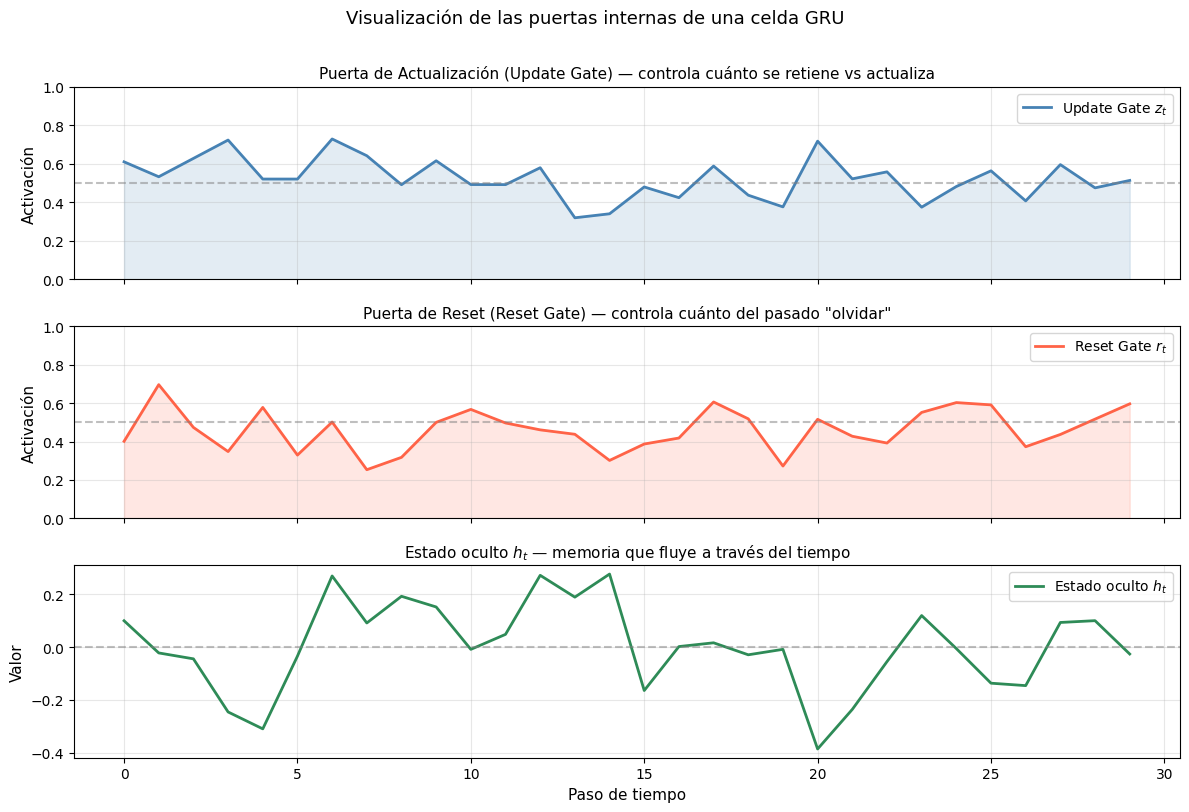


Interpretación:
  Update gate promedio: 0.525 → Tiende a conservar historia
  Reset gate promedio:  0.462 → Activo olvido del pasado


In [ ]:
# ─────────────────────────────────────────────────────
# VISUALIZACIÓN DE LAS PUERTAS DEL GRU
# ─────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x): return 1 / (1 + np.exp(-x))
def tanh(x): return np.tanh(x)

# Simular el paso de tiempo de una celda GRU (valores escalarizados para visualización)
np.random.seed(42)
T = 30  # pasos de tiempo

# Simular señales de las puertas y estado oculto para demostración
z = sigmoid(np.random.randn(T) * 0.5 + 0.2)   # update gate (tendencia a 0.5)
r = sigmoid(np.random.randn(T) * 0.5 - 0.1)   # reset gate
h = np.zeros(T)
h[0] = 0.1
for t in range(1, T):
    h_cand = tanh(np.random.randn() * 0.3 + r[t] * h[t-1] * 0.2)
    h[t] = (1 - z[t]) * h[t-1] + z[t] * h_cand

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(z, color='steelblue', linewidth=2, label='Update Gate $z_t$')
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].fill_between(range(T), 0, z, alpha=0.15, color='steelblue')
axes[0].set_ylabel('Activación', fontsize=11)
axes[0].set_title('Puerta de Actualización (Update Gate) — controla cuánto se retiene vs actualiza', fontsize=11)
axes[0].legend(fontsize=10); axes[0].set_ylim(0, 1); axes[0].grid(True, alpha=0.3)

axes[1].plot(r, color='tomato', linewidth=2, label='Reset Gate $r_t$')
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
axes[1].fill_between(range(T), 0, r, alpha=0.15, color='tomato')
axes[1].set_ylabel('Activación', fontsize=11)
axes[1].set_title('Puerta de Reset (Reset Gate) — controla cuánto del pasado "olvidar"', fontsize=11)
axes[1].legend(fontsize=10); axes[1].set_ylim(0, 1); axes[1].grid(True, alpha=0.3)

axes[2].plot(h, color='seagreen', linewidth=2, label='Estado oculto $h_t$')
axes[2].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[2].set_ylabel('Valor', fontsize=11)
axes[2].set_xlabel('Paso de tiempo', fontsize=11)
axes[2].set_title('Estado oculto $h_t$ — memoria que fluye a través del tiempo', fontsize=11)
axes[2].legend(fontsize=10); axes[2].grid(True, alpha=0.3)

plt.suptitle('Visualización de las puertas internas de una celda GRU', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
print("\nInterpretación:")
print(f"  Update gate promedio: {z.mean():.3f} → {'Tiende a conservar historia' if z.mean() > 0.5 else 'Tiende a actualizar con info nueva'}")
print(f"  Reset gate promedio:  {r.mean():.3f} → {'Poco olvido del pasado' if r.mean() > 0.5 else 'Activo olvido del pasado'}")


---

# 🔬 Visualización Comparativa de las Puertas del LSTM

A diferencia del GRU, el LSTM mantiene **dos flujos de información** separados: el **estado de celda** $C_t$ (memoria a largo plazo) y el **estado oculto** $h_t$ (memoria de trabajo).

## Las cuatro operaciones del LSTM en detalle

### 1. Puerta de olvido (Forget Gate): ¿Qué se borra de la memoria?
$$f_t = \sigma(W_f [h_{t-1}, x_t] + b_f)$$

### 2. Puerta de entrada (Input Gate): ¿Qué información nueva entra?
$$i_t = \sigma(W_i [h_{t-1}, x_t] + b_i)$$
$$\tilde{C}_t = \tanh(W_C [h_{t-1}, x_t] + b_C)$$

### 3. Actualización del estado de celda: Combinar olvido + nueva info
$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$

### 4. Puerta de salida (Output Gate): ¿Qué se expone como estado oculto?
$$o_t = \sigma(W_o [h_{t-1}, x_t] + b_o)$$
$$h_t = o_t \odot \tanh(C_t)$$

El símbolo $\odot$ denota **producto elemento a elemento** (Hadamard).


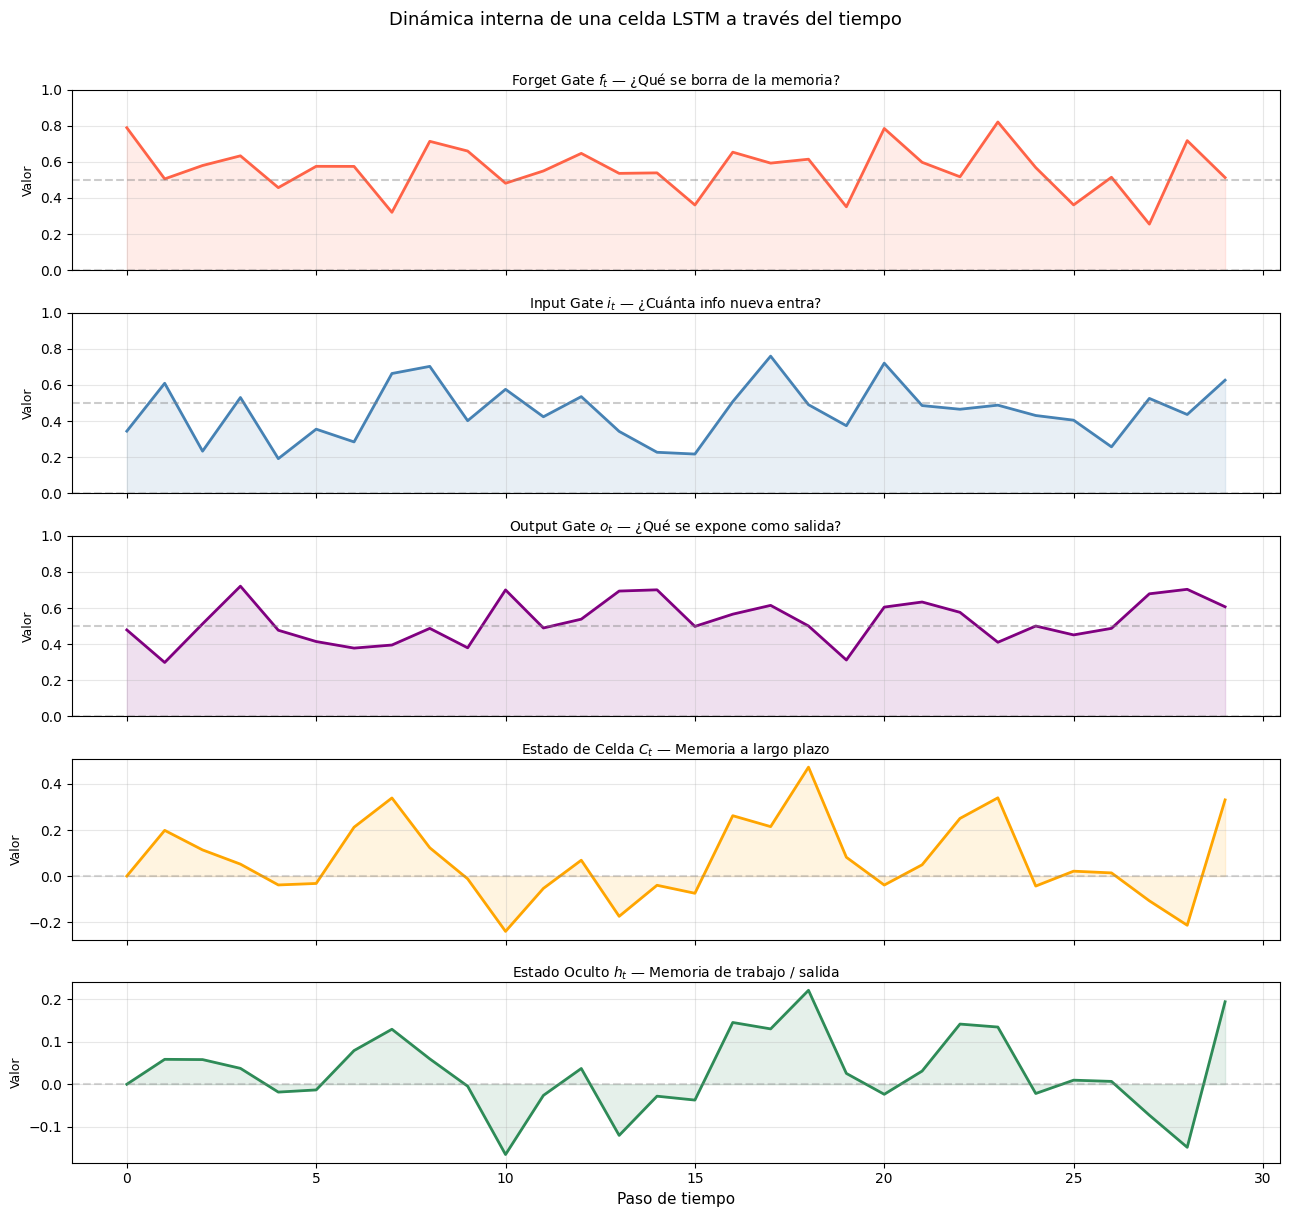


Nota pedagógica:
  • El estado de celda C_t puede mantener información durante muchos pasos (memoria larga)
  • El estado oculto h_t es más 'volátil' y representa la memoria de trabajo
  • Las puertas close to 0 o 1 actúan como interruptores on/off


In [ ]:
# ─────────────────────────────────────────────────────
# VISUALIZACIÓN DE LAS PUERTAS DEL LSTM
# ─────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x): return 1 / (1 + np.exp(-x))

np.random.seed(7)
T = 30

# Simular activaciones de puertas y estados para visualización pedagógica
f = sigmoid(np.random.randn(T) * 0.6 + 0.3)   # forget gate
i = sigmoid(np.random.randn(T) * 0.6 - 0.2)   # input gate
o = sigmoid(np.random.randn(T) * 0.5 + 0.1)   # output gate
C_tilde = np.tanh(np.random.randn(T) * 0.5)    # cell candidate

C = np.zeros(T)
h = np.zeros(T)
for t in range(1, T):
    C[t] = f[t] * C[t-1] + i[t] * C_tilde[t]
    h[t] = o[t] * np.tanh(C[t])

fig, axes = plt.subplots(5, 1, figsize=(13, 12), sharex=True)
configs = [
    (f, 'tomato',    'Forget Gate $f_t$ — ¿Qué se borra de la memoria?', (0, 1)),
    (i, 'steelblue', 'Input Gate $i_t$ — ¿Cuánta info nueva entra?', (0, 1)),
    (o, 'purple',    'Output Gate $o_t$ — ¿Qué se expone como salida?', (0, 1)),
    (C, 'orange',    'Estado de Celda $C_t$ — Memoria a largo plazo', None),
    (h, 'seagreen',  'Estado Oculto $h_t$ — Memoria de trabajo / salida', None),
]

for ax, (signal, color, title, ylim) in zip(axes, configs):
    ax.plot(signal, color=color, linewidth=2)
    ax.fill_between(range(T), 0, signal, alpha=0.12, color=color)
    if ylim: ax.set_ylim(ylim); ax.axhline(0.5, color='gray', linestyle='--', alpha=0.4)
    ax.axhline(0, color='gray', linestyle='--', alpha=0.3)
    ax.set_title(title, fontsize=10, pad=3)
    ax.set_ylabel('Valor', fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Paso de tiempo', fontsize=11)
plt.suptitle('Dinámica interna de una celda LSTM a través del tiempo', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("\nNota pedagógica:")
print("  • El estado de celda C_t puede mantener información durante muchos pasos (memoria larga)")
print("  • El estado oculto h_t es más 'volátil' y representa la memoria de trabajo")
print("  • Las puertas close to 0 o 1 actúan como interruptores on/off")


---

# 📐 2. Matemática de las RNNs — Forward y Backward Pass (Ampliado)

---

## BPTT — Backpropagation Through Time

Cuando desenrollamos una RNN a través de $T$ pasos de tiempo, obtenemos un grafo computacional profundo. El algoritmo **BPTT** aplica la regla de la cadena hacia atrás a través de este grafo.

### El problema del gradiente

El gradiente de la pérdida con respecto al estado oculto en el paso $t$ depende de los gradientes de **todos los pasos futuros**:

$$\frac{\partial L}{\partial h_t} = \frac{\partial L}{\partial h_T} \cdot \prod_{k=t}^{T-1} \frac{\partial h_{k+1}}{\partial h_k}$$

Cada factor $\frac{\partial h_{k+1}}{\partial h_k} = W^T \cdot \text{diag}(f'(h_k))$.

Si los valores propios de $W$ son $< 1$ → gradientes **desaparecen** exponencialmente.  
Si los valores propios de $W$ son $> 1$ → gradientes **explotan** exponencialmente.

### Soluciones implementadas en LSTM/GRU

| Problema | Solución en LSTM/GRU |
|----------|---------------------|
| Gradiente desvanecido | Conexiones de identidad en $C_t$ (LSTM) y $h_t$ (GRU) |
| Gradiente explosivo | Gradient Clipping (`clipnorm`, `clipvalue`) |
| Inestabilidad numérica | Funciones de activación $\sigma$ y $\tanh$ saturadas solo en extremos |

---

## Gradient Clipping en Keras

Keras aplica gradient clipping directamente en el optimizador:

```python
optimizer = tf.keras.optimizers.Adam(clipnorm=1.0)   # Norma máxima del gradiente
# o
optimizer = tf.keras.optimizers.Adam(clipvalue=0.5)  # Valor máximo por componente
```


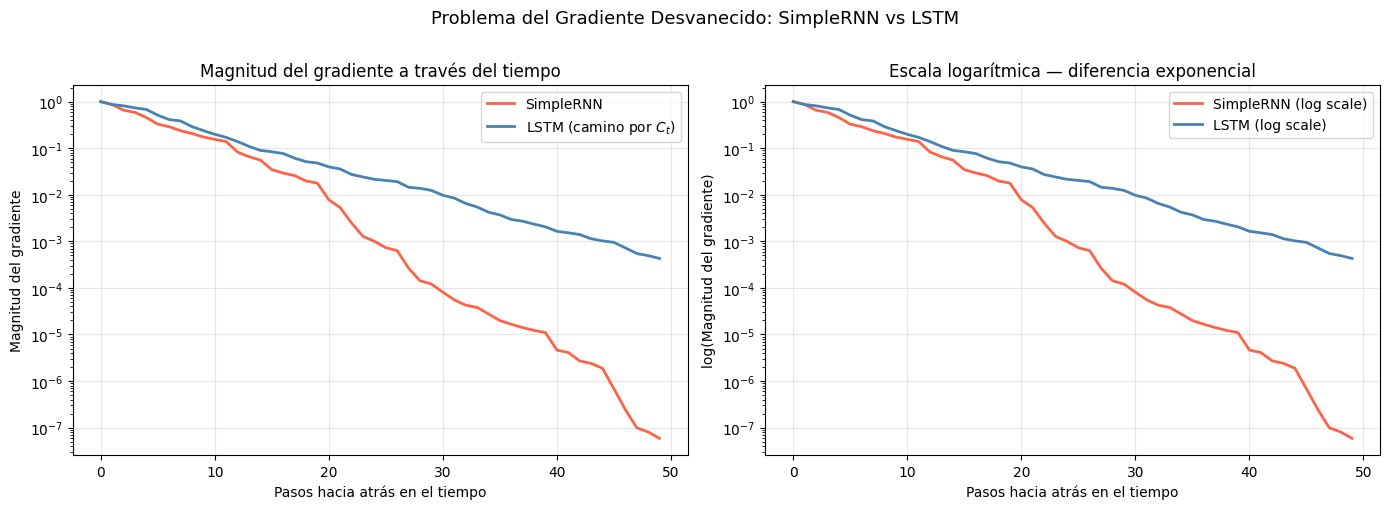


Gradiente en paso 0 (SimpleRNN): 5.87e-08
Gradiente en paso 0 (LSTM):      0.0004

El LSTM mantiene gradientes útiles; el SimpleRNN los pierde casi completamente.


In [ ]:
# ─────────────────────────────────────────────────────
# DEMOSTRACIÓN DEL PROBLEMA DEL GRADIENTE DESVANECIDO
# ─────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

def sigmoid_deriv(x):
    s = 1 / (1 + np.exp(-x))
    return s * (1 - s)

def tanh_deriv(x):
    return 1 - np.tanh(x)**2

# Simular propagación del gradiente hacia atrás en T pasos
T = 50
grad_simple_rnn = np.zeros(T)
grad_lstm_approx = np.zeros(T)

W_rnn  = 0.9   # Peso recurrente en SimpleRNN (< 1 → desvanece)
W_lstm = 1.0   # En LSTM el camino por C_t tiene ganancia ≈ 1

grad_simple_rnn[T-1] = 1.0
grad_lstm_approx[T-1] = 1.0

for t in range(T-2, -1, -1):
    # SimpleRNN: gradiente se multiplica por W * tanh'(activación)
    deriv = tanh_deriv(np.random.randn() * 0.5)   # ≈ 0.4–1.0
    grad_simple_rnn[t] = grad_simple_rnn[t+1] * W_rnn * deriv

    # LSTM: el camino por C_t tiene ganancia ≈ f_t ≈ 0.7–0.95 (puerta de olvido)
    forget = np.random.uniform(0.75, 0.95)
    grad_lstm_approx[t] = grad_lstm_approx[t+1] * forget

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(T-1, -1, -1), grad_simple_rnn, color='tomato', linewidth=2,
         label='SimpleRNN')
ax1.plot(range(T-1, -1, -1), grad_lstm_approx, color='steelblue', linewidth=2,
         label='LSTM (camino por $C_t$)')
ax1.set_title('Magnitud del gradiente a través del tiempo', fontsize=12)
ax1.set_xlabel('Pasos hacia atrás en el tiempo')
ax1.set_ylabel('Magnitud del gradiente')
ax1.legend(); ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

ax2.semilogy(range(T-1, -1, -1), grad_simple_rnn + 1e-15, color='tomato',
             linewidth=2, label='SimpleRNN (log scale)')
ax2.semilogy(range(T-1, -1, -1), grad_lstm_approx, color='steelblue',
             linewidth=2, label='LSTM (log scale)')
ax2.set_title('Escala logarítmica — diferencia exponencial', fontsize=12)
ax2.set_xlabel('Pasos hacia atrás en el tiempo')
ax2.set_ylabel('log(Magnitud del gradiente)')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('Problema del Gradiente Desvanecido: SimpleRNN vs LSTM', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f"\nGradiente en paso 0 (SimpleRNN): {grad_simple_rnn[0]:.2e}")
print(f"Gradiente en paso 0 (LSTM):      {grad_lstm_approx[0]:.4f}")
print("\nEl LSTM mantiene gradientes útiles; el SimpleRNN los pierde casi completamente.")


---

# 🏗️ 3. Tipos de Arquitecturas RNN — Guía Visual

---

Dependiendo de la **longitud de entrada y salida**, las RNNs se configuran de diferente manera.

## One-to-One
- No es realmente recurrente: es una red densa clásica.
- Entrada única → Salida única.
- **Ejemplo**: Clasificación de imagen (aunque CNN es más apropiado).

## One-to-Many
- Una sola entrada → Secuencia de salidas.
- **Ejemplos**: Generación de texto desde una imagen (image captioning), generación de música desde un género.

```python
# En Keras: return_sequences=True en la capa RNN, Dense aplicada en cada paso
LSTM(units=128, return_sequences=True)
TimeDistributed(Dense(vocab_size, activation='softmax'))
```

## Many-to-One
- Secuencia de entradas → Una sola salida.
- **Ejemplos**: Análisis de sentimientos, clasificación de texto, predicción de precio.

```python
# En Keras: return_sequences=False (default)
LSTM(units=128)   # solo retorna el estado final
Dense(1, activation='sigmoid')
```

## Many-to-Many (sincronizado)
- Secuencia de entradas → Secuencia de salidas (misma longitud).
- **Ejemplos**: Reconocimiento de entidades (NER), etiquetado POS.

```python
LSTM(units=128, return_sequences=True)
TimeDistributed(Dense(num_tags, activation='softmax'))
```

## Many-to-Many (no sincronizado / seq2seq)
- Secuencia de entradas → Secuencia de salidas (diferente longitud).
- **Ejemplos**: Traducción automática, resumen de texto, chatbots.
- Requiere arquitectura **Encoder-Decoder**.

```python
# Encoder
encoder_out, state_h, state_c = LSTM(256, return_state=True)(encoder_input)
# Decoder
decoder_out = LSTM(256)(decoder_input, initial_state=[state_h, state_c])
```


---

# 📌 13. Resumen Comparativo y Cuándo Usar Cada Arquitectura

---

## Tabla resumen

| | SimpleRNN | LSTM | GRU |
|--|:---------:|:----:|:---:|
| **Año de introducción** | 1986 | 1997 | 2014 |
| **Parámetros** | Menos | Más | Intermedios |
| **Dependencias largas** | ❌ No | ✅ Sí | ✅ Sí |
| **Velocidad de entrenamiento** | ✅ Rápido | ❌ Lento | ✅ Rápido |
| **Cuándo usarlo** | Prototipado rápido, secuencias cortas | Texto complejo, audio, traducción | Balance velocidad/precisión |

## Cuándo usar cada variante de LSTM/GRU

| Variante | Cuándo | Código |
|---------|--------|--------|
| **LSTM/GRU simple** | Primera opción para la mayoría de tareas | `LSTM(units)` |
| **Apilado** | Datos muy complejos, vocabulario grande | `LSTM(units, return_sequences=True)` → `LSTM(units)` |
| **Bidireccional** | Clasificación de texto, NER (el contexto futuro importa) | `Bidirectional(LSTM(units))` |
| **Apilado + Bidireccional** | Traducción, modelos de comprensión lectora | Combinar ambos |

## El panorama actual

Las RNNs (LSTM/GRU) fueron el **estado del arte** en NLP de 2014 a 2017. Hoy, los **Transformers** (BERT, GPT) dominan NLP gracias a su capacidad de procesar secuencias en paralelo y capturar contexto global.

Sin embargo, las RNNs siguen siendo relevantes para:
- **Inferencia en tiempo real** (bajo costo computacional).
- **Dispositivos edge** con memoria limitada.
- **Series temporales** con ventanas cortas.
- **Aprendizaje pedagógico** de secuencias.

```
Cronología del estado del arte en NLP:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1986   SimpleRNN
1997   LSTM ──────────────────────────────┐
2014   GRU ─────────────────────────────┐ │
2015   Seq2Seq + Attention ─────────────┼─┘
2017   Transformer ─────────────────────┘
2018   BERT / GPT
2020+  GPT-3, T5, LLaMA, Gemini...
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
```


---

# 🏋️ 14. Ejercicios Propuestos

---

**Ejercicio 1 — Explorar window_size**
En el Ejemplo 1 (predicción de serie temporal), varía el `window_size` entre 5, 15 y 30. ¿Cómo afecta el RMSE final? ¿Por qué una ventana demasiado pequeña o demasiado grande puede ser problemática?

**Ejercicio 2 — Gradient Clipping**
Modifica el SimpleRNN del Ejemplo 1 para usar gradient clipping:
```python
model.compile(optimizer=tf.keras.optimizers.Adam(clipnorm=1.0), loss='mse')
```
¿Mejora la convergencia en secuencias más largas?

**Ejercicio 3 — LSTM apilado con Dropout**
Agrega una segunda capa LSTM al modelo de predicción de acciones Tesla:
```python
LSTM(100, return_sequences=True)
Dropout(0.3)
LSTM(50)
```
¿Mejora el RMSE? ¿Hay sobreajuste?

**Ejercicio 4 — GRU Bidireccional para clasificación**
Adapta el modelo de generación de nombres para usar un GRU Bidireccional. ¿Los nombres generados son más coherentes?

**Ejercicio 5 — Temperatura y creatividad**
En el Ejemplo 2 (generación de nombres), genera 20 nombres con temperatura = 0.3 y 20 con temperatura = 1.5. Clasifica subjetivamente cuántos son "reales" vs "inventados". ¿A qué temperatura el modelo es más creativo sin perder coherencia?

**Ejercicio 6 — Comparación con datos reales**
Descarga datos de otra acción (por ejemplo Apple: `AAPL` o Amazon: `AMZN`) y compara el RMSE de LSTM vs GRU. ¿Coincide con el resultado de Tesla?

**Ejercicio 7 — Búsqueda de hiperparámetros con Keras Tuner**
Implementa una búsqueda de hiperparámetros con Keras Tuner para el modelo de predicción de acciones, explorando:
- `units` en [32, 64, 128]
- `dropout` en [0.1, 0.2, 0.3]
- `learning_rate` en [1e-3, 1e-4]

**Ejercicio 8 — Conexión con el Módulo 11**
Después de completar este cuaderno, abra el **Cuaderno 11** (NLP con Embeddings). Identifique en ese cuaderno dónde se usa cada concepto aprendido aquí:
- ¿Dónde se usa la capa LSTM?
- ¿Cómo se conecta la capa Embedding con la capa LSTM?
- ¿Qué representa el `return_sequences` en ese contexto?
